In [1]:
# ==========================================================
# NYC Restaurant Inspections — Unified Analysis
# RQ1, RQ2, and RQ3
# ==========================================================

# ----------------------------------------------------------
# Global Imports
# ----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report
)
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, HistGradientBoostingClassifier,
    GradientBoostingClassifier
)
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils import resample
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# ----------------------------------------------------------
# Load dataset once
# ----------------------------------------------------------
FILE = "DOHMH_New_York_City_Restaurant_Inspection_Results.csv"
df_raw = pd.read_csv(FILE, low_memory=False)
print(f"Data Loaded: {df_raw.shape}")

# Common date parsing
for col in ['INSPECTION DATE', 'GRADE DATE', 'RECORD DATE']:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')

Data Loaded: (289847, 27)


/var/folders/yc/dvwbsbn92dxgf68pvf773wvc0000gn/T/ipykernel_7556/833517311.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')
/var/folders/yc/dvwbsbn92dxgf68pvf773wvc0000gn/T/ipykernel_7556/833517311.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')


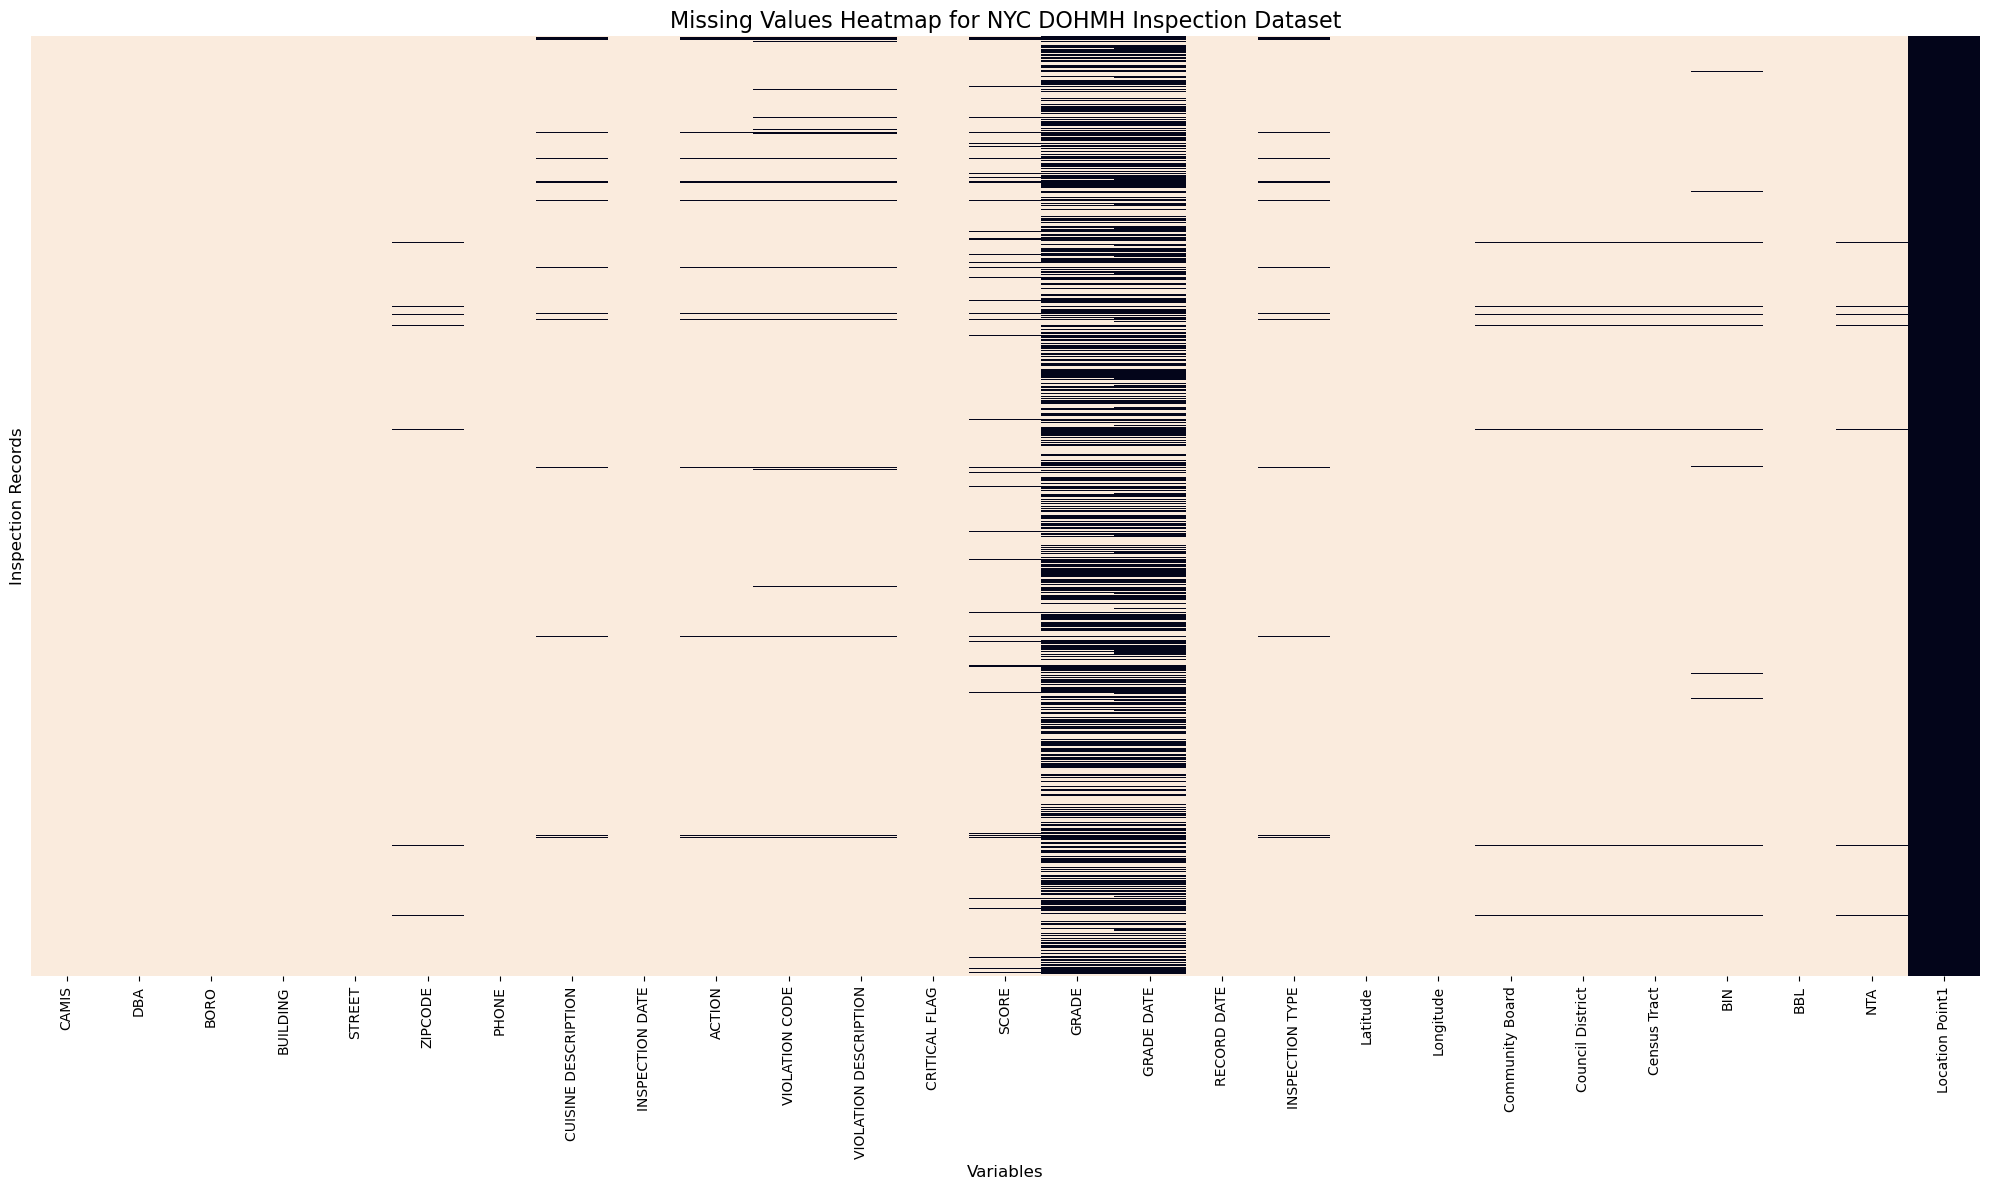

In [3]:
plt.figure(figsize=(20, 12))
sns.heatmap(
    df_raw.isnull(),
    cmap="rocket_r",
    cbar=False,
    yticklabels=False
)

plt.xticks(rotation=90)
plt.title("Missing Values Heatmap for NYC DOHMH Inspection Dataset", fontsize=16)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Inspection Records", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
plt.figure(figsize=(10, 8))
hb = plt.hexbin(
    df_raw["Longitude"], df_raw["Latitude"],
    C=df_raw["SCORE_CLEAN"],
    gridsize=60,
    reduce_C_function=np.mean,
    cmap="coolwarm",
    mincnt=1
)

plt.colorbar(hb, label="Average Inspection Score")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Heatmap of Average Inspection Scores in NYC")
plt.show()

KeyError: 'SCORE_CLEAN'

<Figure size 1000x800 with 0 Axes>

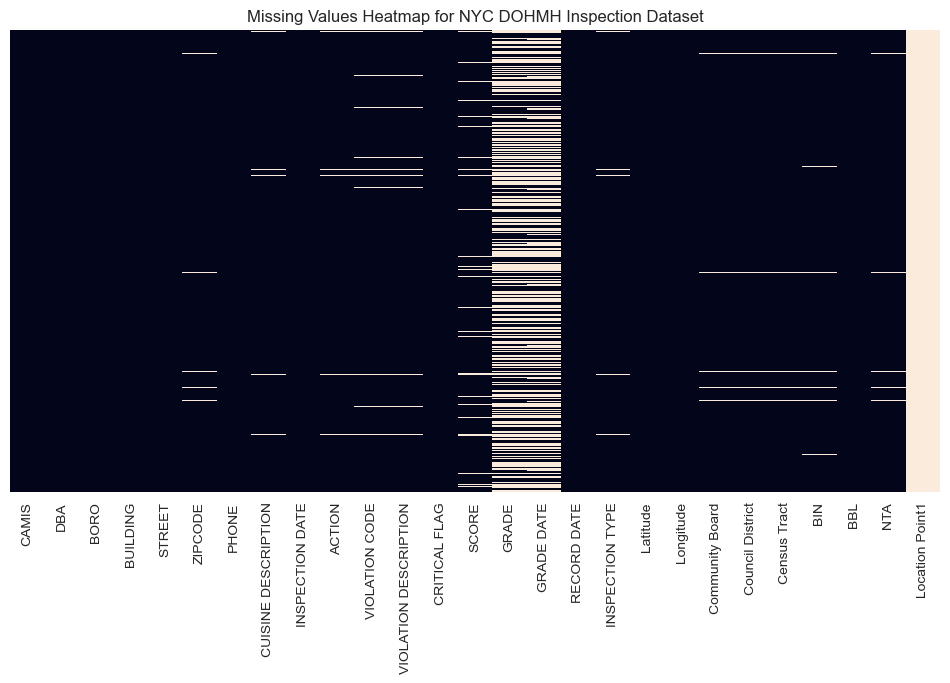

In [29]:
plt.figure(figsize=(12,6))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap for NYC DOHMH Inspection Dataset")
plt.show()


RQ1: How much variation in inspection scores is explained by geography?

RQ1 Model Performance:
               Model   MAE   RMSE     R²
3  Gradient Boosting  8.93  11.61  0.026
1   Ridge Regression  8.93  11.64  0.022
0  Linear Regression  8.94  11.66  0.019
2      Random Forest  9.13  11.97 -0.034

Best Model: Gradient Boosting


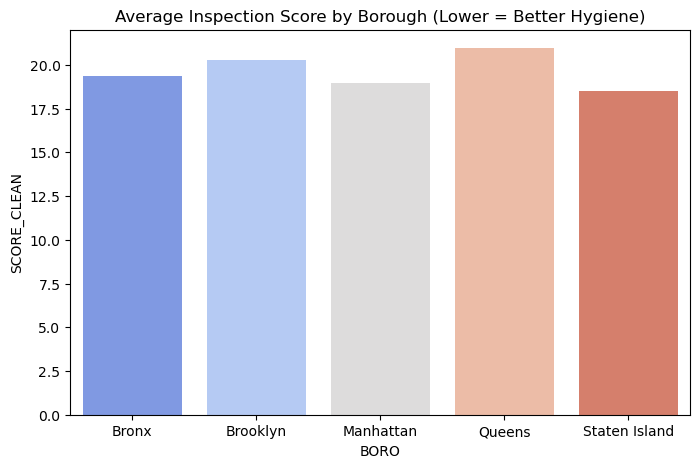

In [20]:
# ----------------------------------------------------------
# RQ1: Geography and Inspection Scores
# ----------------------------------------------------------
print("\n" + "="*60)
print("RQ1: How much variation in inspection scores is explained by geography?")
print("="*60)

df = df_raw.copy()

cols = ['CAMIS', 'BORO', 'ZIPCODE', 'Community Board', 'Council District',
        'NTA', 'Latitude', 'Longitude', 'SCORE']
df = df[cols].dropna(subset=['BORO','ZIPCODE','Latitude','Longitude','SCORE'])
df = df[df['SCORE'] > 0]
df = df[(df['Latitude']>40)&(df['Latitude']<41)&(df['Longitude']<-73)&(df['Longitude']>-75)]
df['SCORE_CLEAN'] = df['SCORE'].clip(upper=80)

df['lat_bin'] = df['Latitude'].round(2)
df['lon_bin'] = df['Longitude'].round(2)
df_geo = df.groupby(['CAMIS','BORO','ZIPCODE','Community Board',
                     'Council District','NTA','lat_bin','lon_bin'],
                    as_index=False)['SCORE_CLEAN'].mean()

X = df_geo[['BORO','ZIPCODE','Community Board','Council District','NTA','lat_bin','lon_bin']]
y = df_geo['SCORE_CLEAN']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

pre_geo = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), X.columns)], remainder='drop')

models_rq1 = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results_rq1 = []
for name, model in models_rq1.items():
    pipe = Pipeline([('pre', pre_geo), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results_rq1.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, y_pred),2),
        "RMSE": round(mean_squared_error(y_test, y_pred, squared=False),2),
        "R²": round(r2_score(y_test, y_pred),3)
    })

rq1_df = pd.DataFrame(results_rq1).sort_values('R²', ascending=False)
print("\nRQ1 Model Performance:")
print(rq1_df)

best_rq1 = rq1_df.iloc[0]['Model']
print(f"\nBest Model: {best_rq1}")

borough_avg = df_geo.groupby('BORO')['SCORE_CLEAN'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=borough_avg, x='BORO', y='SCORE_CLEAN', palette='coolwarm')
plt.title("Average Inspection Score by Borough (Lower = Better Hygiene)")
plt.show()

In [17]:
# Preprocess test data
X_test_pre = pipe.named_steps['pre'].transform(X_test)
feature_names = pipe.named_steps['pre'].get_feature_names_out()

rq1_importance = compute_percent_importance(pipe.named_steps['model'], X_test_pre, y_test, feature_names)
print("\nRQ1 — Percentage Contribution of Each Geographic Variable:")
print(rq1_importance.head(20))

AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

In [5]:
# ==========================================================
# 4️⃣ RQ2 RUN 1: repeat_same_flag (Same Violation Repeated)
# ==========================================================
print("\n" + "="*65)
print("RQ2 RUN 1: Modeling 'repeat_same_flag' (Same Violation Repeated)")
print("="*65)

df = df_raw.copy()
df = df.dropna(subset=['CAMIS','VIOLATION CODE'])
df['CAMIS'] = df['CAMIS'].astype(str)
df['VIOLATION CODE'] = df['VIOLATION CODE'].astype(str)

repeat_counts = df.groupby(['CAMIS','VIOLATION CODE']).size().reset_index(name='violation_repeat_count')
df = df.merge(repeat_counts, on=['CAMIS','VIOLATION CODE'], how='left')

THRESHOLD = 5
repeaters = df[df['violation_repeat_count']>=THRESHOLD]['CAMIS'].unique()
df_filtered = df[~df['CAMIS'].isin(repeaters)].copy()

repeat_any = (
    df_filtered.groupby('CAMIS')['VIOLATION CODE']
    .nunique().reset_index().rename(columns={'VIOLATION CODE':'unique_violation_count'})
)
repeat_any['repeat_flag'] = (repeat_any['unique_violation_count']>1).astype(int)

repeat_same = (
    df.groupby('CAMIS')['violation_repeat_count']
    .max().reset_index().rename(columns={'violation_repeat_count':'max_same_violation'})
)
repeat_same['repeat_same_flag'] = (repeat_same['max_same_violation']>1).astype(int)

df_filtered = (
    df_filtered
    .merge(repeat_any[['CAMIS','repeat_flag']], on='CAMIS', how='left')
    .merge(repeat_same[['CAMIS','repeat_same_flag']], on='CAMIS', how='left')
)
print(f"\nClean dataset ready: {df_filtered.shape}")

# Modeling repeat_same_flag
cat_cols = ['BORO','CUISINE DESCRIPTION','INSPECTION TYPE','CRITICAL FLAG']
num_cols = ['SCORE']
df_model = df_filtered.dropna(subset=cat_cols + num_cols + ['repeat_same_flag']).copy()

y = df_model['repeat_same_flag'].astype(int)
X = df_model[cat_cols + num_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

pre_rq2 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

models_rq2 = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(max_depth=8, random_state=42)
}

results_same, trained_same = [], {}
for name, model in models_rq2.items():
    pipe = Pipeline([('pre', pre_rq2), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1] if hasattr(pipe,"predict_proba") else pipe.decision_function(X_test)
    results_same.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    trained_same[name] = pipe

rq2_same_df = pd.DataFrame(results_same).round(3).sort_values("ROC-AUC", ascending=False)
print("\nRQ2 Run 1 Model Comparison (repeat_same_flag):")
print(rq2_same_df)


RQ2 RUN 1: Modeling 'repeat_same_flag' (Same Violation Repeated)

Clean dataset ready: (255081, 30)

RQ2 Run 1 Model Comparison (repeat_same_flag):
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
2        Random Forest     0.814      0.957   0.824     0.885    0.876
3    Gradient Boosting     0.887      0.903   0.976     0.938    0.848
1        Decision Tree     0.726      0.960   0.715     0.820    0.833
0  Logistic Regression     0.757      0.947   0.765     0.846    0.815


In [6]:
# ==========================================================
# RQ2 RUN 2: repeat_flag (Distinct Violations Repeated)
# ==========================================================
print("\n" + "="*65)
print("RQ2 RUN 2: Modeling 'repeat_flag' (Multiple Distinct Violations)")
print("="*65)

df_model2 = df_filtered.dropna(subset=cat_cols + num_cols + ['repeat_flag']).copy()
y = df_model2['repeat_flag'].astype(int)
X = df_model2[cat_cols + num_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

results_diff, trained_diff = [], {}
for name, model in models_rq2.items():
    pipe = Pipeline([('pre', pre_rq2), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1] if hasattr(pipe,"predict_proba") else pipe.decision_function(X_test)
    results_diff.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    trained_diff[name] = pipe

rq2_diff_df = pd.DataFrame(results_diff).round(3).sort_values("ROC-AUC", ascending=False)
print("\nRQ2 Run 2 Model Comparison (repeat_flag):")
print(rq2_diff_df)


RQ2 RUN 2: Modeling 'repeat_flag' (Multiple Distinct Violations)

RQ2 Run 2 Model Comparison (repeat_flag):
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1        Decision Tree     0.943      1.000   0.943     0.971    0.975
0  Logistic Regression     0.914      1.000   0.914     0.955    0.968
3    Gradient Boosting     0.996      0.998   0.999     0.998    0.923
2        Random Forest     0.982      0.998   0.983     0.991    0.922


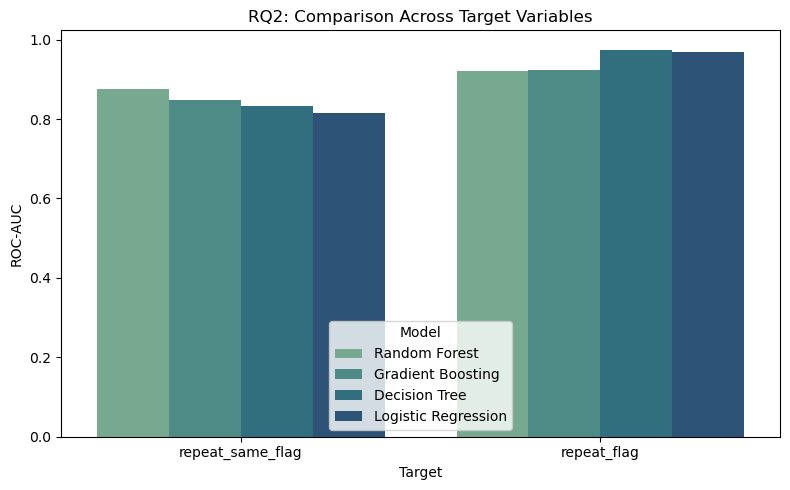


Combined RQ2 Results:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Target
0,Random Forest,0.814,0.957,0.824,0.885,0.876,repeat_same_flag
1,Gradient Boosting,0.887,0.903,0.976,0.938,0.848,repeat_same_flag
2,Decision Tree,0.726,0.960,0.715,0.820,0.833,repeat_same_flag
3,Logistic Regression,0.757,0.947,0.765,0.846,0.815,repeat_same_flag
4,Decision Tree,0.943,1.000,0.943,0.971,0.975,repeat_flag
5,Logistic Regression,0.914,1.000,0.914,0.955,0.968,repeat_flag
6,Gradient Boosting,0.996,0.998,0.999,0.998,0.923,repeat_flag
7,Random Forest,0.982,0.998,0.983,0.991,0.922,repeat_flag


In [7]:
# ==========================================================
# COMBINED COMPARISON
# ==========================================================
summary_rq2 = pd.concat([
    rq2_same_df.assign(Target="repeat_same_flag"),
    rq2_diff_df.assign(Target="repeat_flag")
]).reset_index(drop=True)

plt.figure(figsize=(8,5))
sns.barplot(data=summary_rq2, x="Target", y="ROC-AUC", hue="Model", palette="crest")
plt.title("RQ2: Comparison Across Target Variables")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

print("\nCombined RQ2 Results:")
display(summary_rq2)


RQ2 Feature Importance Analysis (Best Model by Accuracy)

RQ2 Run 1 Best Model (Accuracy): Gradient Boosting


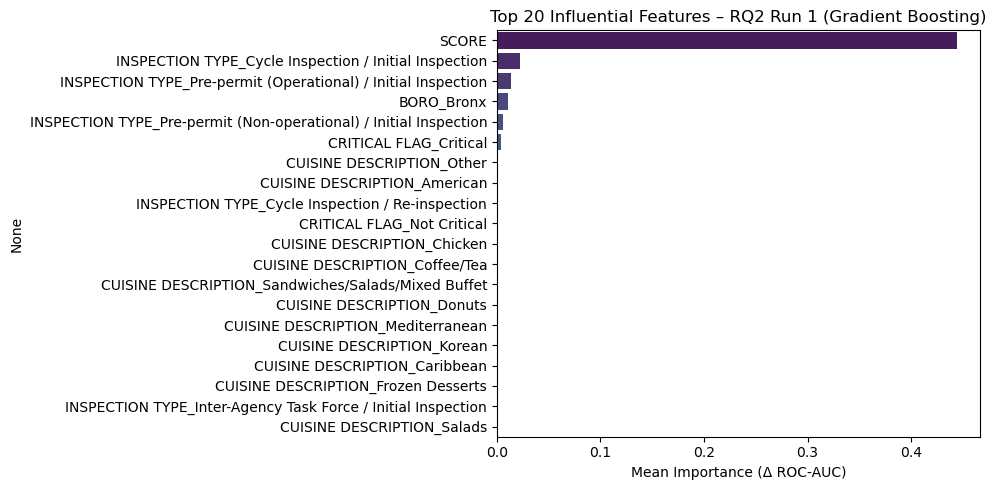


Top 20 Most Influential Features (RQ2 Run 1):
SCORE                                                                0.444374
INSPECTION TYPE_Cycle Inspection / Initial Inspection                0.022729
INSPECTION TYPE_Pre-permit (Operational) / Initial Inspection        0.014032
BORO_Bronx                                                           0.010553
INSPECTION TYPE_Pre-permit (Non-operational) / Initial Inspection    0.006330
CRITICAL FLAG_Critical                                               0.004114
CUISINE DESCRIPTION_Other                                            0.001255
CUISINE DESCRIPTION_American                                         0.000745
INSPECTION TYPE_Cycle Inspection / Re-inspection                     0.000657
CRITICAL FLAG_Not Critical                                           0.000554
CUISINE DESCRIPTION_Chicken                                          0.000129
CUISINE DESCRIPTION_Coffee/Tea                                       0.000072
CUISINE DESCRIPTI

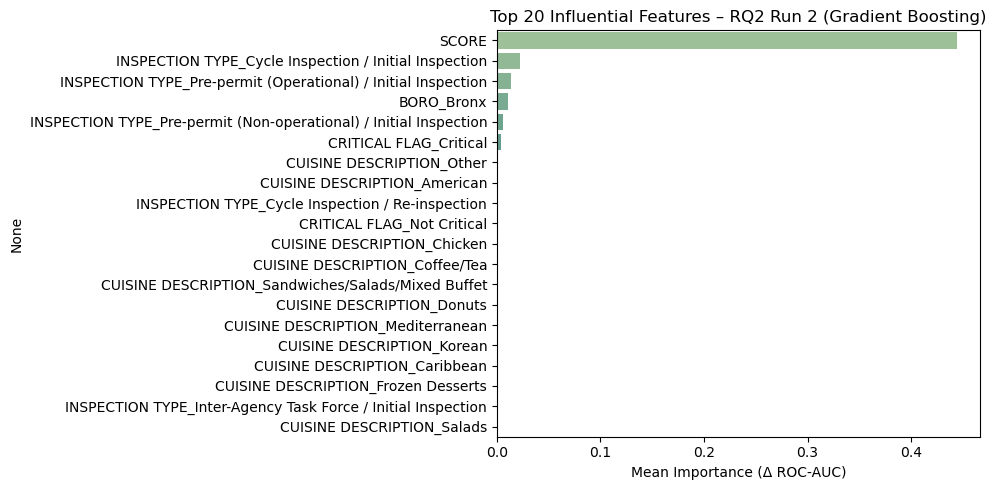


Top 20 Most Influential Features (RQ2 Run 2):
SCORE                                                                0.444374
INSPECTION TYPE_Cycle Inspection / Initial Inspection                0.022729
INSPECTION TYPE_Pre-permit (Operational) / Initial Inspection        0.014032
BORO_Bronx                                                           0.010553
INSPECTION TYPE_Pre-permit (Non-operational) / Initial Inspection    0.006330
CRITICAL FLAG_Critical                                               0.004114
CUISINE DESCRIPTION_Other                                            0.001255
CUISINE DESCRIPTION_American                                         0.000745
INSPECTION TYPE_Cycle Inspection / Re-inspection                     0.000657
CRITICAL FLAG_Not Critical                                           0.000554
CUISINE DESCRIPTION_Chicken                                          0.000129
CUISINE DESCRIPTION_Coffee/Tea                                       0.000072
CUISINE DESCRIPTI

In [8]:
# ==========================================================
# Feature Importance for Both RQ2 Runs (Best Model by Accuracy)
# ==========================================================

print("\n" + "="*65)
print("RQ2 Feature Importance Analysis (Best Model by Accuracy)")
print("="*65)

# ---------- RUN 1: repeat_same_flag ----------
best_rq2_run1 = rq2_same_df.loc[rq2_same_df['Accuracy'].idxmax(), 'Model']
best_pipe_run1 = trained_same[best_rq2_run1]

print(f"\nRQ2 Run 1 Best Model (Accuracy): {best_rq2_run1}")

X_encoded1 = best_pipe_run1.named_steps['pre'].transform(X_test)
expected_n1 = best_pipe_run1.named_steps['model'].n_features_in_
if X_encoded1.shape[1] != expected_n1:
    diff = expected_n1 - X_encoded1.shape[1]
    X_encoded1 = np.hstack([X_encoded1, np.zeros((X_encoded1.shape[0], diff))]) if diff > 0 else X_encoded1[:, :expected_n1]

encoded_features1 = best_pipe_run1.named_steps["pre"].transformers_[0][1].get_feature_names_out(cat_cols)
feature_names1 = np.concatenate([encoded_features1, num_cols])[:expected_n1]

r1 = permutation_importance(best_pipe_run1.named_steps['model'], X_encoded1, y_test,
                            n_repeats=10, random_state=42, scoring="roc_auc")

top20_run1 = pd.Series(r1.importances_mean, index=feature_names1).sort_values(ascending=False).head(20)

plt.figure(figsize=(10,5))
sns.barplot(x=top20_run1.values, y=top20_run1.index, palette="viridis")
plt.title(f"Top 20 Influential Features – RQ2 Run 1 ({best_rq2_run1})")
plt.xlabel("Mean Importance (Δ ROC-AUC)")
plt.tight_layout()
plt.show()

print("\nTop 20 Most Influential Features (RQ2 Run 1):")
print(top20_run1.round(6))


# ---------- RUN 2: repeat_flag ----------
best_rq2_run2 = rq2_diff_df.loc[rq2_diff_df['Accuracy'].idxmax(), 'Model']
best_pipe_run2 = trained_diff[best_rq2_run2]

print(f"\nRQ2 Run 2 Best Model (Accuracy): {best_rq2_run2}")

X_encoded2 = best_pipe_run2.named_steps['pre'].transform(X_test)
expected_n2 = best_pipe_run2.named_steps['model'].n_features_in_
if X_encoded2.shape[1] != expected_n2:
    diff = expected_n2 - X_encoded2.shape[1]
    X_encoded2 = np.hstack([X_encoded2, np.zeros((X_encoded2.shape[0], diff))]) if diff > 0 else X_encoded2[:, :expected_n2]

encoded_features2 = best_pipe_run2.named_steps["pre"].transformers_[0][1].get_feature_names_out(cat_cols)
feature_names2 = np.concatenate([encoded_features2, num_cols])[:expected_n2]

r2 = permutation_importance(best_pipe_run2.named_steps['model'], X_encoded2, y_test,
                            n_repeats=10, random_state=42, scoring="roc_auc")

top20_run2 = pd.Series(r2.importances_mean, index=feature_names2).sort_values(ascending=False).head(20)

plt.figure(figsize=(10,5))
sns.barplot(x=top20_run2.values, y=top20_run2.index, palette="crest")
plt.title(f"Top 20 Influential Features – RQ2 Run 2 ({best_rq2_run2})")
plt.xlabel("Mean Importance (Δ ROC-AUC)")
plt.tight_layout()
plt.show()

print("\nTop 20 Most Influential Features (RQ2 Run 2):")
print(top20_run2.round(6))



RQ3: Are certain cuisines more associated with severe violations?

RQ3 Model Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
2        Random Forest     0.876      0.978   0.876     0.922    0.656
3    Gradient Boosting     0.662      0.977   0.662     0.785    0.618
1        Decision Tree     0.736      0.977   0.736     0.836    0.595
0  Logistic Regression     0.600      0.976   0.600     0.738    0.576

Best model: Random Forest


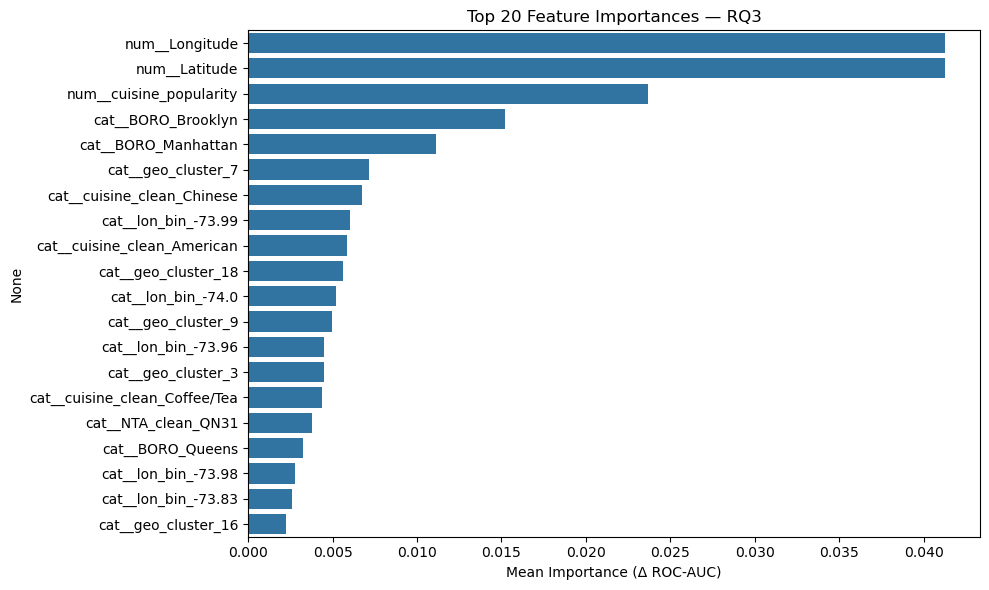


Top 20 Most Influential Features:
num__Longitude                   0.041268
num__Latitude                    0.041262
num__cuisine_popularity          0.023658
cat__BORO_Brooklyn               0.015236
cat__BORO_Manhattan              0.011109
cat__geo_cluster_7               0.007175
cat__cuisine_clean_Chinese       0.006756
cat__lon_bin_-73.99              0.006011
cat__cuisine_clean_American      0.005826
cat__geo_cluster_18              0.005641
cat__lon_bin_-74.0               0.005189
cat__geo_cluster_9               0.004957
cat__lon_bin_-73.96              0.004487
cat__geo_cluster_3               0.004482
cat__cuisine_clean_Coffee/Tea    0.004356
cat__NTA_clean_QN31              0.003804
cat__BORO_Queens                 0.003277
cat__lon_bin_-73.98              0.002798
cat__lon_bin_-73.83              0.002617
cat__geo_cluster_16              0.002254
dtype: float64


In [9]:
# ==========================================================
# RQ3: Cuisine-Type Risks Given Geography
# ==========================================================
print("\n" + "="*65)
print("RQ3: Are certain cuisines more associated with severe violations?")
print("="*65)

df = df_raw.copy()
dupe_keys = [k for k in ["CAMIS","INSPECTION DATE","VIOLATION CODE"] if k in df.columns]
if dupe_keys: df = df.drop_duplicates(subset=dupe_keys)
df = df.dropna(subset=['BORO','CUISINE DESCRIPTION','Latitude','Longitude','CRITICAL FLAG'])
df = df[(df['Latitude']>40)&(df['Latitude']<41)&(df['Longitude']>-75)&(df['Longitude']<-73)]
df['severe_violation'] = np.where(df['CRITICAL FLAG'].str.contains('Critical', case=False, na=False), 1, 0)

c_counts = df['CUISINE DESCRIPTION'].value_counts()
rare = c_counts[c_counts<100].index
df['cuisine_clean'] = df['CUISINE DESCRIPTION'].replace(rare,'Other')
df['cuisine_popularity'] = df['cuisine_clean'].map(df['cuisine_clean'].value_counts(normalize=True))
df['lat_bin'] = df['Latitude'].round(2)
df['lon_bin'] = df['Longitude'].round(2)
df['geo_cluster'] = KMeans(n_clusters=20, n_init=10, random_state=42).fit_predict(df[['Latitude','Longitude']])
df['cuisine_boro'] = df['cuisine_clean'] + " | " + df['BORO']
nta_counts = df['NTA'].value_counts()
nta_rare = nta_counts[nta_counts<200].index
df['NTA_clean'] = df['NTA'].replace(nta_rare,'NTA_Other')

cat_cols = ['cuisine_clean','BORO','NTA_clean','cuisine_boro','lat_bin','lon_bin','geo_cluster']
num_cols = ['Latitude','Longitude','cuisine_popularity']
features = cat_cols + num_cols
target = 'severe_violation'

df_model = df.dropna(subset=features+[target])
X = df_model[features]; y = df_model[target].astype(int)

# balance
X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)
train_df = X_train.copy(); train_df['target'] = y_train
maj, minr = train_df[train_df['target']==1], train_df[train_df['target']==0]
minr_up = resample(minr, replace=True, n_samples=len(maj), random_state=42)
train_bal = pd.concat([maj,minr_up])
X_train_bal, y_train_bal = train_bal.drop(columns=['target']), train_bal['target']

# preprocessing + MI
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])
Xtr_enc = pre.fit_transform(X_train_bal); Xte_enc = pre.transform(X_test)
feat_names = pre.get_feature_names_out()
mi_scores = mutual_info_classif(Xtr_enc, y_train_bal, random_state=42)
mi_series = pd.Series(mi_scores, index=feat_names).sort_values(ascending=False)
K = min(50, Xtr_enc.shape[1]); topk_idx = [np.where(feat_names==nm)[0][0] for nm in mi_series.head(K).index]

class ColumnSubselector:
    def __init__(self, idx): self.idx = np.array(idx)
    def fit(self, X, y=None): self.n_features_in_ = X.shape[1]; return self
    def transform(self, X):
        if hasattr(X,"toarray"): X = X.toarray()
        return X[:, self.idx]

models_rq3 = {
    "Logistic Regression": LogisticRegression(max_iter=400, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results_rq3, trained_pipes = [], {}
for name, clf in models_rq3.items():
    pipe = Pipeline([('pre', pre), ('keep', ColumnSubselector(topk_idx)), ('model', clf)])
    pipe.fit(X_train_bal, y_train_bal)
    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:,1] if hasattr(pipe.named_steps['model'],'predict_proba') else pipe.decision_function(X_test)
    auc = roc_auc_score(y_test, y_score)
    rep = classification_report(y_test, y_pred, output_dict=True)
    results_rq3.append({
        "Model": name, "Accuracy": rep["accuracy"],
        "Precision": rep["weighted avg"]["precision"],
        "Recall": rep["weighted avg"]["recall"],
        "F1-Score": rep["weighted avg"]["f1-score"], "ROC-AUC": auc
    })
    trained_pipes[name] = pipe

rq3_df = pd.DataFrame(results_rq3).round(3).sort_values("ROC-AUC", ascending=False)
print("\nRQ3 Model Comparison:")
print(rq3_df)

best_rq3 = rq3_df.iloc[0]['Model']
best_pipe = trained_pipes[best_rq3]
print(f"\nBest model: {best_rq3}")

# permutation importance
Xte_pre = best_pipe.named_steps['pre'].transform(X_test)
Xte_sel = best_pipe.named_steps['keep'].transform(Xte_pre)
kept_names = [feat_names[i] for i in topk_idx]
perm = permutation_importance(best_pipe.named_steps['model'], Xte_sel, y_test, n_repeats=10, random_state=42, scoring='roc_auc')
perm_series = pd.Series(perm.importances_mean, index=kept_names).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=perm_series.values, y=perm_series.index)
plt.title("Top 20 Feature Importances — RQ3")
plt.xlabel("Mean Importance (Δ ROC-AUC)")
plt.tight_layout()
plt.show()
print("\nTop 20 Most Influential Features:")
print(perm_series)


RQ3 (Updated): Cuisine dummies + Geography (no ColumnTransformer)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Updated RQ3 Model Comparison (dummies):
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
2        Random Forest     0.876      0.978   0.876     0.922    0.652
3    Gradient Boosting     0.660      0.977   0.660     0.783    0.608
1        Decision Tree     0.577      0.977   0.577     0.720    0.598
0  Logistic Regression     0.591      0.976   0.591     0.731    0.571

Best model: Random Forest


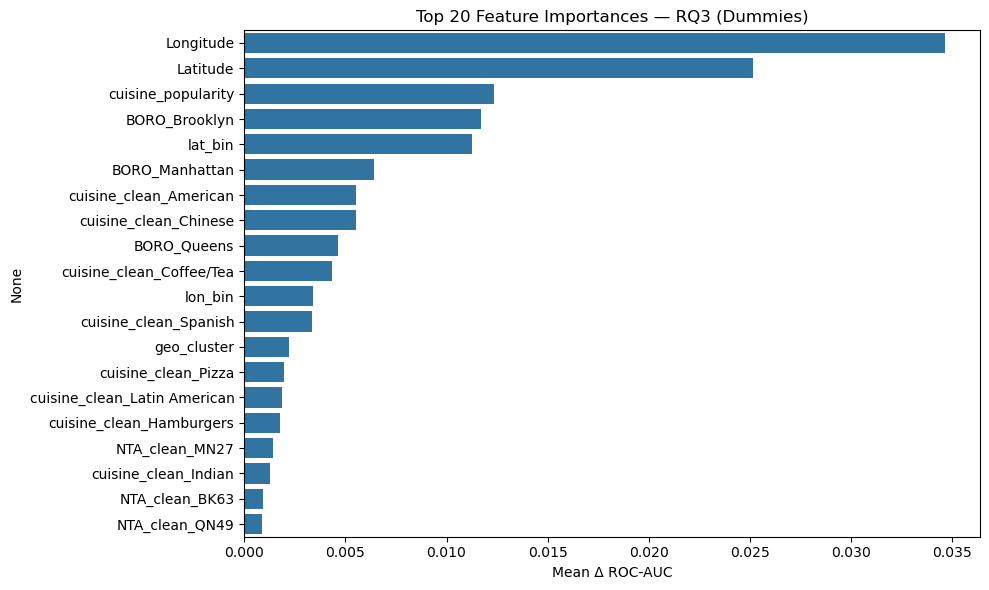


Top 20 Most Influential Features (names are post-dummy columns):
Longitude                       0.034632
Latitude                        0.025141
cuisine_popularity              0.012366
BORO_Brooklyn                   0.011696
lat_bin                         0.011275
BORO_Manhattan                  0.006417
cuisine_clean_American          0.005545
cuisine_clean_Chinese           0.005531
BORO_Queens                     0.004616
cuisine_clean_Coffee/Tea        0.004351
lon_bin                         0.003385
cuisine_clean_Spanish           0.003336
geo_cluster                     0.002219
cuisine_clean_Pizza             0.001953
cuisine_clean_Latin American    0.001882
cuisine_clean_Hamburgers        0.001773
NTA_clean_MN27                  0.001424
cuisine_clean_Indian            0.001290
NTA_clean_BK63                  0.000911
NTA_clean_QN49                  0.000897
dtype: float64


In [12]:
# ==========================================================
# RQ3: Cuisine-Type Risks Given Geography (One-Hot dummies)
# ==========================================================
print("\n" + "="*65)
print("RQ3 (Updated): Cuisine dummies + Geography (no ColumnTransformer)")
print("="*65)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) Load & basic cleaning
# -----------------------------
df = df_raw.copy()

# Drop exact duplicate inspection rows by restaurant-date-violation
dupe_keys = [k for k in ["CAMIS","INSPECTION DATE","VIOLATION CODE"] if k in df.columns]
if dupe_keys:
    df = df.drop_duplicates(subset=dupe_keys, keep="first")

# Keep required fields; NYC bounding box
df = df.dropna(subset=['BORO','CUISINE DESCRIPTION','Latitude','Longitude','CRITICAL FLAG'])
df = df[(df['Latitude']>40)&(df['Latitude']<41)&(df['Longitude']>-75)&(df['Longitude']<-73)]

# Target: severe (critical) violation
df['severe_violation'] = df['CRITICAL FLAG'].str.contains('Critical', case=False, na=False).astype(int)

# -----------------------------
# 2) Cuisine cleanup + dummies
# -----------------------------
c_counts = df['CUISINE DESCRIPTION'].value_counts()
rare = c_counts[c_counts < 100].index
df['cuisine_clean'] = df['CUISINE DESCRIPTION'].replace(rare, 'Other')

# Popularity of cuisine (as proportion)
df['cuisine_popularity'] = df['cuisine_clean'].map(df['cuisine_clean'].value_counts(normalize=True))

# -----------------------------
# 3) Geography features
# -----------------------------
df['lat_bin'] = df['Latitude'].round(2)
df['lon_bin'] = df['Longitude'].round(2)
df['geo_cluster'] = KMeans(n_clusters=20, n_init=10, random_state=42).fit_predict(df[['Latitude','Longitude']])

# NTA cleanup
if 'NTA' in df.columns:
    nta_counts = df['NTA'].value_counts()
    nta_rare = nta_counts[nta_counts < 200].index
    df['NTA_clean'] = df['NTA'].replace(nta_rare, 'NTA_Other')
else:
    df['NTA_clean'] = 'NTA_Other'  # fallback if missing

# -----------------------------
# 4) One-hot encode categoricals (including cuisine)
#    -> everything becomes numeric in one DataFrame
# -----------------------------
cat_cols = ['BORO','NTA_clean','lat_bin','lon_bin','geo_cluster','cuisine_clean']
num_cols = ['Latitude','Longitude','cuisine_popularity']

# Drop rows with any NA in our modeling cols
df_model = df.dropna(subset=cat_cols + num_cols + ['severe_violation']).copy()

# Pandas get_dummies for ALL categoricals (includes cuisine)
X_cat = pd.get_dummies(df_model[cat_cols], drop_first=False)  # keep full set; tree models handle it
X_num = df_model[num_cols].copy()

# Combine features
X_df = pd.concat([X_num, X_cat], axis=1)
y = df_model['severe_violation'].astype(int)

# -----------------------------
# 5) Train/test split + balance
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, stratify=y, test_size=0.2, random_state=42
)

# Balance: upsample minority to the majority count (based on training set)
train_df = X_train.copy()
train_df['target'] = y_train
n_pos = (train_df['target']==1).sum()
n_neg = (train_df['target']==0).sum()

if n_pos >= n_neg:
    maj = train_df[train_df['target']==1]
    minr = train_df[train_df['target']==0]
    minr_up = resample(minr, replace=True, n_samples=len(maj), random_state=42)
else:
    maj = train_df[train_df['target']==0]
    minr = train_df[train_df['target']==1]
    minr_up = resample(minr, replace=True, n_samples=len(maj), random_state=42)

train_bal = pd.concat([maj, minr_up], ignore_index=True)
X_train_bal = train_bal.drop(columns=['target'])
y_train_bal = train_bal['target']

# -----------------------------
# 6) Scale numeric columns ONLY
# -----------------------------
scaler = StandardScaler()
X_train_bal_scaled = X_train_bal.copy()
X_test_scaled = X_test.copy()

X_train_bal_scaled[num_cols] = scaler.fit_transform(X_train_bal[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# -----------------------------
# 7) Mutual information feature filter (top K)
# -----------------------------
# (MI works on dense numeric arrays; we already have that)
mi_scores = mutual_info_classif(X_train_bal_scaled.values, y_train_bal.values, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_bal_scaled.columns).sort_values(ascending=False)

TOP_K = min(50, len(mi_series))
keep_cols = mi_series.head(TOP_K).index.tolist()

Xtr = X_train_bal_scaled[keep_cols].values
Xte = X_test_scaled[keep_cols].values

# -----------------------------
# 8) Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=400, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
fitted = {}

for name, clf in models.items():
    clf.fit(Xtr, y_train_bal)
    y_pred = clf.predict(Xte)

    # scores for AUC
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(Xte)[:,1]
    else:
        y_score = clf.decision_function(Xte)

    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": round(rep["accuracy"], 3),
        "Precision": round(rep["weighted avg"]["precision"], 3),
        "Recall": round(rep["weighted avg"]["recall"], 3),
        "F1-Score": round(rep["weighted avg"]["f1-score"], 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_score), 3)
    })
    fitted[name] = clf

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("\nUpdated RQ3 Model Comparison (dummies):")
print(results_df)

best_name = results_df.iloc[0]["Model"]
best_clf = fitted[best_name]
print(f"\nBest model: {best_name}")

# -----------------------------
# 9) Permutation Importance on best model
# -----------------------------
perm = permutation_importance(
    best_clf, Xte, y_test, n_repeats=10, random_state=42, scoring="roc_auc"
)
perm_series = pd.Series(perm.importances_mean, index=keep_cols).sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=perm_series.values, y=perm_series.index)
plt.title("Top 20 Feature Importances — RQ3 (Dummies)")
plt.xlabel("Mean Δ ROC-AUC")
plt.tight_layout()
plt.show()

print("\nTop 20 Most Influential Features (names are post-dummy columns):")
print(perm_series)



RQ3 (Deep Analysis): Cuisine Types + Dummies + Geography Interaction

================ Cuisine Types (Raw) ================

CUISINE DESCRIPTION
American                          44594
Chinese                           28076
Coffee/Tea                        20199
Pizza                             17434
Latin American                    12342
Mexican                           11686
Bakery Products/Desserts          11371
Caribbean                         10557
Japanese                          10070
Italian                            9395
Chicken                            7533
Spanish                            7007
Asian/Asian Fusion                 5489
Juice, Smoothies, Fruit Salads     5185
Sandwiches                         5132
Donuts                             5095
Thai                               4453
Indian                             4446
Korean                             4401
Hamburgers                         4197
Jewish/Kosher                      4134
Mediterranean 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



================ Updated RQ3 Model Performance ================

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
2        Random Forest     0.876      0.978   0.876     0.922    0.652
3    Gradient Boosting     0.660      0.977   0.660     0.783    0.608
1        Decision Tree     0.577      0.977   0.577     0.720    0.598
0  Logistic Regression     0.591      0.976   0.591     0.731    0.571

✅ Best Model: Random Forest


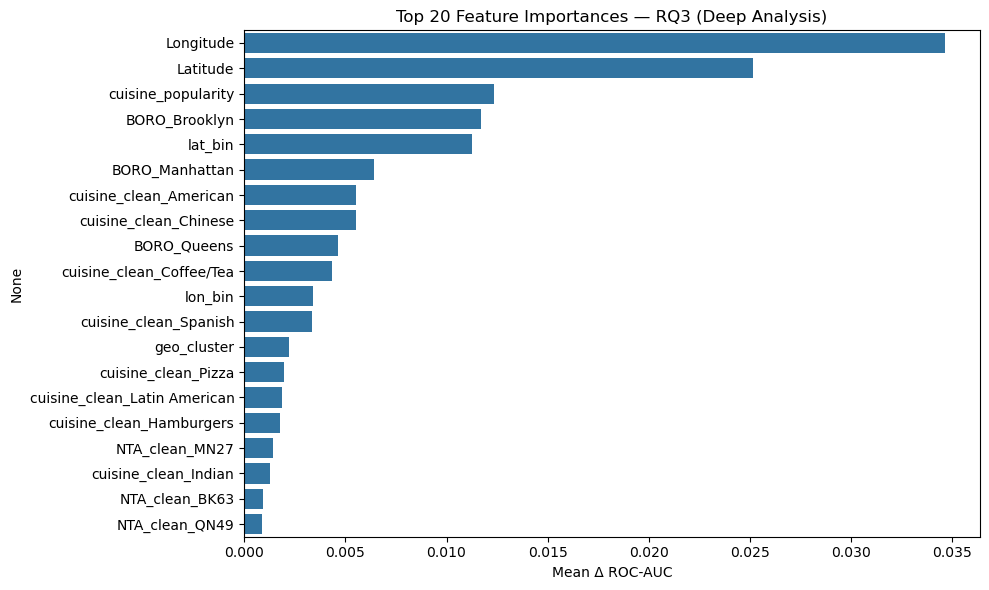


================ Top 20 Most Influential Features ================

Longitude                       0.034632
Latitude                        0.025141
cuisine_popularity              0.012366
BORO_Brooklyn                   0.011696
lat_bin                         0.011275
BORO_Manhattan                  0.006417
cuisine_clean_American          0.005545
cuisine_clean_Chinese           0.005531
BORO_Queens                     0.004616
cuisine_clean_Coffee/Tea        0.004351
lon_bin                         0.003385
cuisine_clean_Spanish           0.003336
geo_cluster                     0.002219
cuisine_clean_Pizza             0.001953
cuisine_clean_Latin American    0.001882
cuisine_clean_Hamburgers        0.001773
NTA_clean_MN27                  0.001424
cuisine_clean_Indian            0.001290
NTA_clean_BK63                  0.000911
NTA_clean_QN49                  0.000897
dtype: float64


In [15]:
# ==========================================================
# RQ3: Deep Analysis -- Cuisine-Type Risks Given Geography
# ==========================================================
print("\n" + "="*70)
print("RQ3 (Deep Analysis): Cuisine Types + Dummies + Geography Interaction")
print("="*70)

# ----------------------------------------------------------
# STEP 1 — Load & Basic Cleaning
# ----------------------------------------------------------
df = df_raw.copy()

# Remove exact duplicates
dupe_keys = ["CAMIS","INSPECTION DATE","VIOLATION CODE"]
dupe_keys = [c for c in dupe_keys if c in df.columns]
df = df.drop_duplicates(subset=dupe_keys, keep="first")

# Keep valid rows
df = df.dropna(subset=["BORO","CUISINE DESCRIPTION","Latitude","Longitude","CRITICAL FLAG"])

# NYC bounding box filter
df = df[(df["Latitude"]>40)&(df["Latitude"]<41)&(df["Longitude"]>-75)&(df["Longitude"]<-73)]

# Create target variable: severe violation
df["severe_violation"] = df["CRITICAL FLAG"].str.contains("Critical", case=False, na=False).astype(int)

# ----------------------------------------------------------
# STEP 2 — Cuisine Exploration (DEEP ANALYSIS)
# ----------------------------------------------------------
print("\n================ Cuisine Types (Raw) ================\n")
print(df["CUISINE DESCRIPTION"].value_counts().to_string())

# Identify rare cuisines (<100 records)
cuisine_counts = df["CUISINE DESCRIPTION"].value_counts()
rare_cuisines = cuisine_counts[cuisine_counts < 100].index

print("\n================ Rare Cuisines (<100 records) ================\n")
print(rare_cuisines.to_list())

# Replace rare cuisines with "Other"
df["cuisine_clean"] = df["CUISINE DESCRIPTION"].replace(rare_cuisines, "Other")

print("\n================ Cleaned Cuisine Categories (After Grouping) ================\n")
print(df["cuisine_clean"].value_counts().to_string())

# Cuisine popularity (proportion)
df["cuisine_popularity"] = df["cuisine_clean"].map(
    df["cuisine_clean"].value_counts(normalize=True)
)
# ----------------------------------------------------------
# STEP 3 — Geography Features
# ----------------------------------------------------------
df["lat_bin"] = df["Latitude"].round(2)
df["lon_bin"] = df["Longitude"].round(2)

# KMeans geoclusters (to capture micro-neighborhoods)
df["geo_cluster"] = KMeans(n_clusters=20, n_init=10, random_state=42).fit_predict(
    df[["Latitude","Longitude"]]
)

# Clean NTA groups
if "NTA" in df.columns:
    nta_counts = df["NTA"].value_counts()
    rare_ntas = nta_counts[nta_counts < 200].index
    df["NTA_clean"] = df["NTA"].replace(rare_ntas, "NTA_Other")
else:
    df["NTA_clean"] = "NTA_Other"

# ----------------------------------------------------------
# STEP 4 — One-Hot Encode ALL categorical vars (including cuisine)
# ----------------------------------------------------------
categorical_cols = ["BORO","NTA_clean","lat_bin","lon_bin","geo_cluster","cuisine_clean"]
numeric_cols = ["Latitude","Longitude","cuisine_popularity"]

df_model = df.dropna(subset=categorical_cols + numeric_cols + ["severe_violation"])

# Dummy encoding for ALL categorical features
X_cat = pd.get_dummies(df_model[categorical_cols], drop_first=False)
X_num = df_model[numeric_cols].copy()

# Merge numerical + dummy vars
X = pd.concat([X_num, X_cat], axis=1)
y = df_model["severe_violation"].astype(int)

# ----------------------------------------------------------
# STEP 5 — Train/Test Split + Upsample Minority Class
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

train_df = X_train.copy()
train_df["target"] = y_train

n_pos = (train_df["target"]==1).sum()
n_neg = (train_df["target"]==0).sum()

if n_pos > n_neg:
    majority = train_df[train_df["target"]==1]
    minority = train_df[train_df["target"]==0]
else:
    majority = train_df[train_df["target"]==0]
    minority = train_df[train_df["target"]==1]

minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=42)
train_bal = pd.concat([majority, minority_up], ignore_index=True)

X_train_bal = train_bal.drop(columns=["target"])
y_train_bal = train_bal["target"]

# ----------------------------------------------------------
# STEP 6 — Scale Numeric Columns Only
# ----------------------------------------------------------
scaler = StandardScaler()
X_train_bal_scaled = X_train_bal.copy()
X_test_scaled = X_test.copy()

X_train_bal_scaled[numeric_cols] = scaler.fit_transform(X_train_bal[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ----------------------------------------------------------
# STEP 7 — Feature Selection (Mutual Information)
# ----------------------------------------------------------
mi_scores = mutual_info_classif(X_train_bal_scaled.values, y_train_bal.values, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_bal_scaled.columns).sort_values(ascending=False)

TOP_K = min(50, len(mi_series))
keep_features = mi_series.head(TOP_K).index.tolist()

Xtr = X_train_bal_scaled[keep_features].values
Xte = X_test_scaled[keep_features].values

# ----------------------------------------------------------
# STEP 8 — Train Models
# ----------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=400, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
fitted_models = {}

for name, clf in models.items():
    clf.fit(Xtr, y_train_bal)
    y_pred = clf.predict(Xte)

    y_score = clf.predict_proba(Xte)[:,1] if hasattr(clf,"predict_proba") else clf.decision_function(Xte)

    metrics = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": round(metrics["accuracy"],3),
        "Precision": round(metrics["weighted avg"]["precision"],3),
        "Recall": round(metrics["weighted avg"]["recall"],3),
        "F1-Score": round(metrics["weighted avg"]["f1-score"],3),
        "ROC-AUC": round(roc_auc_score(y_test, y_score),3)
    })

    fitted_models[name] = clf

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("\n================ Updated RQ3 Model Performance ================\n")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print(f"\n✅ Best Model: {best_model_name}")

# ----------------------------------------------------------
# STEP 9 — Permutation Importance
# ----------------------------------------------------------
perm = permutation_importance(
    best_model, Xte, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc"
)

perm_series = pd.Series(perm.importances_mean, index=keep_features).sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=perm_series.values, y=perm_series.index)
plt.title("Top 20 Feature Importances — RQ3 (Deep Analysis)")
plt.xlabel("Mean Δ ROC-AUC")
plt.tight_layout()
plt.show()

print("\n================ Top 20 Most Influential Features ================\n")
print(perm_series)



========== RQ3 (NO BINS) MODEL RESULTS ==========

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0        Random Forest     0.876      0.978   0.876     0.922    0.649
1    Gradient Boosting     0.669      0.977   0.669     0.790    0.607
3  Logistic Regression     0.589      0.977   0.589     0.730    0.603
2        Decision Tree     0.756      0.977   0.756     0.849    0.602

Top 20 Feature Importances:

                               feature  importance
281                     num__Longitude    0.022428
280                      num__Latitude    0.017306
72                  cat__BORO_Brooklyn    0.013070
267                 cat__geo_cluster_7    0.007050
71                     cat__BORO_Bronx    0.006943
2          cat__cuisine_clean_American    0.006330
261                 cat__geo_cluster_1    0.005783
73                 cat__BORO_Manhattan    0.005515
13          cat__cuisine_clean_Chinese    0.005002
269                 cat__geo_cluster_9    0.004742
2

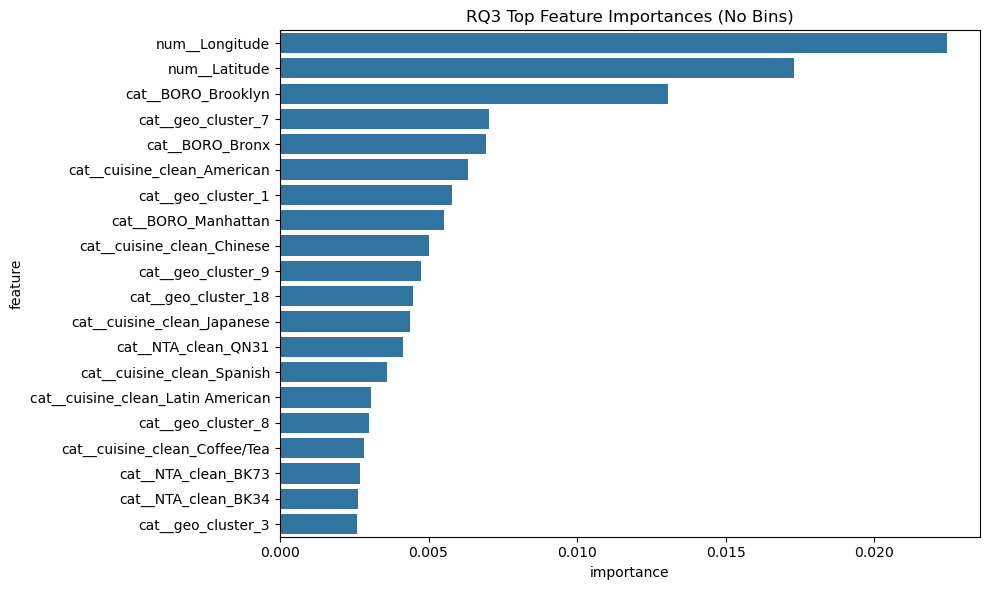

In [16]:
# ==========================================================
# RQ3: Cuisine-Type Risks Given Geography (NO BINS)
# ==========================================================
# -------------------------------
# Load & Clean
# -------------------------------
df = df_raw.copy()

dupe_keys = ["CAMIS","INSPECTION DATE","VIOLATION CODE"]
df = df.drop_duplicates(subset=[c for c in dupe_keys if c in df.columns])

df = df.dropna(subset=['BORO','CUISINE DESCRIPTION','Latitude','Longitude','CRITICAL FLAG'])
df = df[(df['Latitude']>40)&(df['Latitude']<41)&
        (df['Longitude']>-75)&(df['Longitude']<-73)]

# Severe violation flag
df['severe_violation'] = np.where(
    df['CRITICAL FLAG'].str.contains("Critical", case=False, na=False), 
    1, 0
)

# -------------------------------
# Cuisine Cleaning
# -------------------------------
c_counts = df['CUISINE DESCRIPTION'].value_counts()
rare = c_counts[c_counts < 100].index
df['cuisine_clean'] = df['CUISINE DESCRIPTION'].replace(rare, "Other")

df['cuisine_popularity'] = df['cuisine_clean'].map(
    df['cuisine_clean'].value_counts(normalize=True)
)

# -------------------------------
# Keep geography (NO bins)
# -------------------------------
# KMeans geo-cluster
df['geo_cluster'] = KMeans(
    n_clusters=20, n_init=10, random_state=42
).fit_predict(df[['Latitude','Longitude']])

# Clean NTA (group small)
nta_counts = df['NTA'].value_counts()
nta_rare = nta_counts[nta_counts < 200].index
df['NTA_clean'] = df['NTA'].replace(nta_rare, "NTA_Other")

# -------------------------------
# Features & Target
# -------------------------------
cat_cols = [
    'cuisine_clean',   # One-hot
    'BORO',
    'NTA_clean',
    'geo_cluster'
]

num_cols = [
    'Latitude',
    'Longitude',
    'cuisine_popularity'
]

target = 'severe_violation'

df_model = df.dropna(subset=cat_cols + num_cols + [target]).copy()

X = df_model[cat_cols + num_cols]
y = df_model[target].astype(int)

# -------------------------------
# Train-test & Balancing
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

train_df = X_train.copy()
train_df['target'] = y_train

maj = train_df[train_df['target'] == 1]
minr = train_df[train_df['target'] == 0]

minr_up = resample(minr, replace=True, n_samples=len(maj), random_state=42)
train_bal = pd.concat([maj, minr_up])

X_train_bal = train_bal.drop(columns=['target'])
y_train_bal = train_bal['target']

# -------------------------------
# Preprocessing
# -------------------------------
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

feat_names = pre.fit(X_train_bal).get_feature_names_out()
Xtr_enc = pre.transform(X_train_bal)
Xte_enc = pre.transform(X_test)

# -------------------------------
# Models
# -------------------------------
models_rq3 = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=400, class_weight='balanced')
}

results = []
trained = {}

for name, clf in models_rq3.items():
    clf.fit(Xtr_enc, y_train_bal)
    y_pred = clf.predict(Xte_enc)
    y_score = clf.predict_proba(Xte_enc)[:,1] if hasattr(clf, "predict_proba") else clf.decision_function(Xte_enc)
    rep = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        "Model": name,
        "Accuracy": rep['accuracy'],
        "Precision": rep['weighted avg']['precision'],
        "Recall": rep['weighted avg']['recall'],
        "F1-Score": rep['weighted avg']['f1-score'],
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })
    trained[name] = clf

rq3_results = pd.DataFrame(results).round(3).sort_values("ROC-AUC", ascending=False)
print("\n\n========== RQ3 (NO BINS) MODEL RESULTS ==========\n")
print(rq3_results)

best_model_name = rq3_results.iloc[0]['Model']
best_model = trained[best_model_name]

# -------------------------------
# Permutation Importance
# -------------------------------
perm = permutation_importance(
    best_model, Xte_enc, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': feat_names,
    'importance': perm.importances_mean
}).sort_values(by='importance', ascending=False).head(20)

print("\nTop 20 Feature Importances:\n")
print(perm_df)

plt.figure(figsize=(10,6))
sns.barplot(data=perm_df, x='importance', y='feature')
plt.title("RQ3 Top Feature Importances (No Bins)")
plt.tight_layout()
plt.show()


#Fresh Start

In [21]:
# ==========================================================
# NYC Restaurant Inspections — Unified Analysis (Updated)
# RQ1, RQ2, and RQ3 with full metrics + % variable contributions
# ==========================================================

# ----------------------
# Global Imports
# ----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, HistGradientBoostingClassifier,
    GradientBoostingClassifier
)
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils import resample
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ----------------------
# NEW: helpers
# ----------------------
def print_classification_metrics(y_true, y_pred, y_score, label=""):
    """Print full metrics + confusion matrix; return dict for tabulation."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_score)
    cm = confusion_matrix(y_true, y_pred)
    rep = classification_report(y_true, y_pred, digits=3)
    print(f"\n--- {label} ---")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-Score:  {f1:.3f}")
    print(f"ROC-AUC:   {auc:.3f}")
    print("Confusion Matrix [tn, fp; fn, tp]:")
    print(cm)
    print("\nClassification Report:\n", rep)
    return {
        "Model": label, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1, "ROC-AUC": auc
    }

def _encoded_feature_names(pre: ColumnTransformer, cat_cols, num_cols):
    cat_names = []
    # Find the OneHotEncoder step labeled 'cat'
    for name, trans, cols in pre.transformers_:
        if name == 'cat':
            cat_names = trans.get_feature_names_out(cat_cols)
    num_names = [f"num__{c}" for c in num_cols]
    return np.array(list(cat_names) + num_names)

def _group_indices_from_pre(pre: ColumnTransformer, cat_cols, num_cols):
    """
    Map original columns -> list of encoded column indices.
    Returns dict {orig_col: [indices...]} and the full encoded feature name array.
    """
    feat_names = _encoded_feature_names(pre, cat_cols, num_cols)
    groups = {}
    # Categorical groups by OHE prefix 'cat__<col>_...'
    for c in cat_cols:
        prefix = f"cat__{c}_"
        idx = np.where(np.char.startswith(feat_names.astype(str), prefix))[0]
        groups[c] = idx.tolist()
    # Numeric groups by exact name 'num__<col>'
    for c in num_cols:
        name = f"num__{c}"
        idx = np.where(feat_names == name)[0]
        groups[c] = idx.tolist()
    return groups, feat_names

def grouped_permutation_importance(pipe: Pipeline, X, y, cat_cols, num_cols, scoring="roc_auc", n_repeats=10, random_state=42):
    """
    Compute grouped permutation importance on a fitted Pipeline(preprocessor, model).
    For regression: scoring='r2' → returns ΔR² per group; For classification: scoring='roc_auc' → ΔAUC.
    Output: DataFrame with columns ['feature_group', 'delta_score', 'percent_contribution'] sorted by importance.
    """
    # Baseline score
    if scoring == "r2":
        baseline = r2_score(y, pipe.predict(X))
    else:
        # need scores/probas for AUC
        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X)[:, 1]
        else:
            y_score = pipe.decision_function(X)
        baseline = roc_auc_score(y, y_score)

    # Get encoded matrix and group indices
    pre = pipe.named_steps['pre']
    X_enc = pre.transform(X)
    groups, feat_names = _group_indices_from_pre(pre, cat_cols, num_cols)

    # For each group, permute its encoded columns jointly
    rng = np.random.default_rng(seed=random_state)
    drops = []
    for gname, idxs in groups.items():
        X_perm = X_enc.copy()
        if len(idxs) == 0:
            continue
        for _ in range(n_repeats):
            # permute columns jointly by shuffling rows
            perm_idx = rng.permutation(X_perm.shape[0])
            X_perm[:, idxs] = X_perm[perm_idx][:, idxs]
        # Predict with model step only (bypass pre since already encoded)
        model = pipe.named_steps['model']
        # Ensure shapes match
        if hasattr(model, 'n_features_in_') and model.n_features_in_ != X_perm.shape[1]:
            need = model.n_features_in_
            if X_perm.shape[1] < need:
                X_perm = np.hstack([X_perm, np.zeros((X_perm.shape[0], need - X_perm.shape[1]))])
            elif X_perm.shape[1] > need:
                X_perm = X_perm[:, :need]
        if scoring == "r2":
            pred = model.predict(X_perm)
            score = r2_score(y, pred)
        else:
            if hasattr(model, "predict_proba"):
                score = roc_auc_score(y, model.predict_proba(X_perm)[:, 1])
            else:
                score = roc_auc_score(y, model.decision_function(X_perm))
        drops.append((gname, max(0.0, baseline - score)))  # no negative importance
    df = pd.DataFrame(drops, columns=["feature_group", "delta_score"])
    total = df["delta_score"].sum()
    if total > 0:
        df["percent_contribution"] = 100 * df["delta_score"] / total
    else:
        df["percent_contribution"] = 0.0
    df = df.sort_values("delta_score", ascending=False).reset_index(drop=True)
    return df, baseline

# ----------------------
# Load dataset once
# ----------------------
FILE = "DOHMH_New_York_City_Restaurant_Inspection_Results.csv"
df_raw = pd.read_csv(FILE, low_memory=False)
print(f"Data Loaded: {df_raw.shape}")

for col in ['INSPECTION DATE', 'GRADE DATE', 'RECORD DATE']:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')

Data Loaded: (289847, 27)


/var/folders/yc/dvwbsbn92dxgf68pvf773wvc0000gn/T/ipykernel_1149/24105700.py:161: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')
/var/folders/yc/dvwbsbn92dxgf68pvf773wvc0000gn/T/ipykernel_1149/24105700.py:161: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')



RQ1: How much variation in inspection scores is explained by geography?

RQ1 Model Performance:
               Model   MAE   RMSE     R²
3  Gradient Boosting  8.93  11.61  0.026
1   Ridge Regression  8.93  11.64  0.022
0  Linear Regression  8.94  11.66  0.019
2      Random Forest  9.13  11.97 -0.034

Best Model: Gradient Boosting

RQ1: Grouped Permutation Importance (ΔR² and % of total ΔR²):
Empty DataFrame
Columns: [feature_group, delta_score, percent_contribution]
Index: []

RQ1 Baseline R² (best model): 0.026


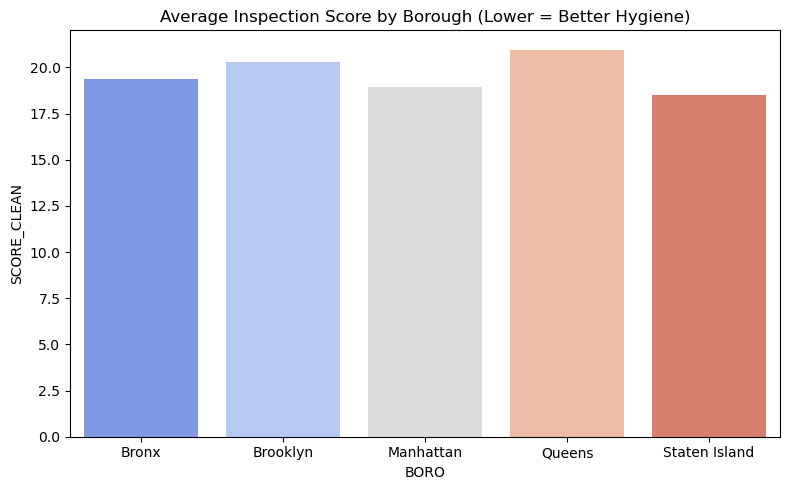

In [22]:
# ==========================================================
# RQ1: Geography → SCORE variation (R² + % contribution)
# ==========================================================
print("\n" + "="*60)
print("RQ1: How much variation in inspection scores is explained by geography?")
print("="*60)

df = df_raw.copy()
cols = ['CAMIS', 'BORO', 'ZIPCODE', 'Community Board', 'Council District',
        'NTA', 'Latitude', 'Longitude', 'SCORE']
df = df[cols].dropna(subset=['BORO','ZIPCODE','Latitude','Longitude','SCORE'])
df = df[(df['SCORE'] > 0)]
df = df[(df['Latitude']>40)&(df['Latitude']<41)&(df['Longitude']<-73)&(df['Longitude']>-75)]
df['SCORE_CLEAN'] = df['SCORE'].clip(upper=80)

# Fine-grained location bins (treated as categorical)
df['lat_bin'] = df['Latitude'].round(2)
df['lon_bin'] = df['Longitude'].round(2)

df_geo = df.groupby(
    ['CAMIS','BORO','ZIPCODE','Community Board','Council District','NTA','lat_bin','lon_bin'],
    as_index=False
)['SCORE_CLEAN'].mean()

X = df_geo[['BORO','ZIPCODE','Community Board','Council District','NTA','lat_bin','lon_bin']]
y = df_geo['SCORE_CLEAN']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

cat_cols_rq1 = list(X.columns)  # all categorical here
num_cols_rq1 = []               # no numeric in preprocessor (lat/long used as bins)

pre_geo = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_rq1)
], remainder='drop')

models_rq1 = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0),
    "Random Forest":      RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting":  GradientBoostingRegressor(random_state=42)
}

results_rq1 = []
pipes_rq1 = {}
for name, model in models_rq1.items():
    pipe = Pipeline([('pre', pre_geo), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results_rq1.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, y_pred),2),
        "RMSE": round(mean_squared_error(y_test, y_pred, squared=False),2),
        "R²": round(r2_score(y_test, y_pred),3)
    })
    pipes_rq1[name] = pipe

rq1_df = pd.DataFrame(results_rq1).sort_values('R²', ascending=False)
print("\nRQ1 Model Performance:")
print(rq1_df)

best_rq1_name = rq1_df.iloc[0]['Model']
best_rq1_pipe = pipes_rq1[best_rq1_name]
print(f"\nBest Model: {best_rq1_name}")

# NEW: Grouped permutation importance → % of R² by geographic variable
gi_rq1_df, r2_baseline = grouped_permutation_importance(
    best_rq1_pipe, X_test, y_test,
    cat_cols=cat_cols_rq1, num_cols=num_cols_rq1,
    scoring="r2", n_repeats=10, random_state=42
)
print("\nRQ1: Grouped Permutation Importance (ΔR² and % of total ΔR²):")
print(gi_rq1_df.round(3))
print(f"\nRQ1 Baseline R² (best model): {r2_baseline:.3f}")

# Optional: quick borough plot (kept from your version)
borough_avg = df_geo.groupby('BORO')['SCORE_CLEAN'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=borough_avg, x='BORO', y='SCORE_CLEAN', palette='coolwarm')
plt.title("Average Inspection Score by Borough (Lower = Better Hygiene)")
plt.tight_layout()
plt.show()

In [23]:
# ==========================================================
# RQ2 RUN 1: repeat_same_flag (Same Violation Repeated)
# with full metrics + grouped % AUC (includes CRITICAL FLAG)
# ==========================================================
print("\n" + "="*65)
print("RQ2 RUN 1: Modeling 'repeat_same_flag' (Same Violation Repeated)")
print("="*65)

df = df_raw.copy()
df = df.dropna(subset=['CAMIS','VIOLATION CODE'])
df['CAMIS'] = df['CAMIS'].astype(str)
df['VIOLATION CODE'] = df['VIOLATION CODE'].astype(str)

repeat_counts = df.groupby(['CAMIS','VIOLATION CODE']).size().reset_index(name='violation_repeat_count')
df = df.merge(repeat_counts, on=['CAMIS','VIOLATION CODE'], how='left')

THRESHOLD = 5
repeaters = df[df['violation_repeat_count']>=THRESHOLD]['CAMIS'].unique()
df_filtered = df[~df['CAMIS'].isin(repeaters)].copy()

repeat_any = (
    df_filtered.groupby('CAMIS')['VIOLATION CODE']
    .nunique().reset_index().rename(columns={'VIOLATION CODE':'unique_violation_count'})
)
repeat_any['repeat_flag'] = (repeat_any['unique_violation_count']>1).astype(int)

repeat_same = (
    df.groupby('CAMIS')['violation_repeat_count']
    .max().reset_index().rename(columns={'violation_repeat_count':'max_same_violation'})
)
repeat_same['repeat_same_flag'] = (repeat_same['max_same_violation']>1).astype(int)

df_filtered = (
    df_filtered
    .merge(repeat_any[['CAMIS','repeat_flag']], on='CAMIS', how='left')
    .merge(repeat_same[['CAMIS','repeat_same_flag']], on='CAMIS', how='left')
)
print(f"\nClean dataset ready: {df_filtered.shape}")

cat_cols = ['BORO','CUISINE DESCRIPTION','INSPECTION TYPE','CRITICAL FLAG']
num_cols = ['SCORE']
df_model = df_filtered.dropna(subset=cat_cols + num_cols + ['repeat_same_flag']).copy()

y = df_model['repeat_same_flag'].astype(int)
X = df_model[cat_cols + num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

pre_rq2 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

models_rq2 = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42),
    "Gradient Boosting":   HistGradientBoostingClassifier(max_depth=8, random_state=42)
}

results_same, trained_same = [], {}
for name, model in models_rq2.items():
    pipe = Pipeline([('pre', pre_rq2), ('model', model)])
    pipe.fit(X_train, y_train)
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    else:
        y_score = pipe.decision_function(X_test)
    y_pred = pipe.predict(X_test)
    metrics = print_classification_metrics(y_test, y_pred, y_score, label=f"RQ2 Run1 - {name}")
    results_same.append(metrics)
    trained_same[name] = pipe

rq2_same_df = pd.DataFrame(results_same).round(3).sort_values("ROC-AUC", ascending=False)
print("\nRQ2 Run 1 Model Comparison (repeat_same_flag):")
print(rq2_same_df)

# NEW: Grouped permutation importance on BEST AUC model (shows CRITICAL FLAG %)
best_rq2_run1_name = rq2_same_df.iloc[0]['Model'].replace("RQ2 Run1 - ", "")
best_pipe_run1 = trained_same[best_rq2_run1_name]

gi_rq2_run1_df, auc_baseline_r1 = grouped_permutation_importance(
    best_rq2_run1, X_test, y_test,
    cat_cols=cat_cols, num_cols=num_cols,
    scoring="roc_auc", n_repeats=10, random_state=42
) if (best_rq2_run1 := best_pipe_run1) else (None, None)

print("\nRQ2 Run 1: Grouped Permutation Importance (ΔAUC and % of total ΔAUC):")
print(gi_rq2_run1_df.round(3))
print(f"\nRQ2 Run 1 Baseline ROC-AUC (best model): {auc_baseline_r1:.3f}")
# Tip: Look up row 'CRITICAL FLAG' here to answer professor’s question directly.



RQ2 RUN 1: Modeling 'repeat_same_flag' (Same Violation Repeated)

Clean dataset ready: (255081, 30)

--- RQ2 Run1 - Logistic Regression ---
Accuracy:  0.757
Precision: 0.947
Recall:    0.765
F1-Score:  0.846
ROC-AUC:   0.815
Confusion Matrix [tn, fp; fn, tp]:
[[ 4423  1824]
 [10052 32641]]

Classification Report:
               precision    recall  f1-score   support

           0      0.306     0.708     0.427      6247
           1      0.947     0.765     0.846     42693

    accuracy                          0.757     48940
   macro avg      0.626     0.736     0.636     48940
weighted avg      0.865     0.757     0.793     48940


--- RQ2 Run1 - Decision Tree ---
Accuracy:  0.726
Precision: 0.960
Recall:    0.715
F1-Score:  0.820
ROC-AUC:   0.833
Confusion Matrix [tn, fp; fn, tp]:
[[ 4977  1270]
 [12149 30544]]

Classification Report:
               precision    recall  f1-score   support

           0      0.291     0.797     0.426      6247
           1      0.960     0.715    


RQ2 RUN 2: Modeling 'repeat_flag' (Multiple Distinct Violations)

--- RQ2 Run2 - Logistic Regression ---
Accuracy:  0.914
Precision: 1.000
Recall:    0.914
F1-Score:  0.955
ROC-AUC:   0.968
Confusion Matrix [tn, fp; fn, tp]:
[[  157    12]
 [ 4198 44573]]

Classification Report:
               precision    recall  f1-score   support

           0      0.036     0.929     0.069       169
           1      1.000     0.914     0.955     48771

    accuracy                          0.914     48940
   macro avg      0.518     0.921     0.512     48940
weighted avg      0.996     0.914     0.952     48940


--- RQ2 Run2 - Decision Tree ---
Accuracy:  0.943
Precision: 1.000
Recall:    0.943
F1-Score:  0.971
ROC-AUC:   0.975
Confusion Matrix [tn, fp; fn, tp]:
[[  164     5]
 [ 2779 45992]]

Classification Report:
               precision    recall  f1-score   support

           0      0.056     0.970     0.105       169
           1      1.000     0.943     0.971     48771

    accuracy     

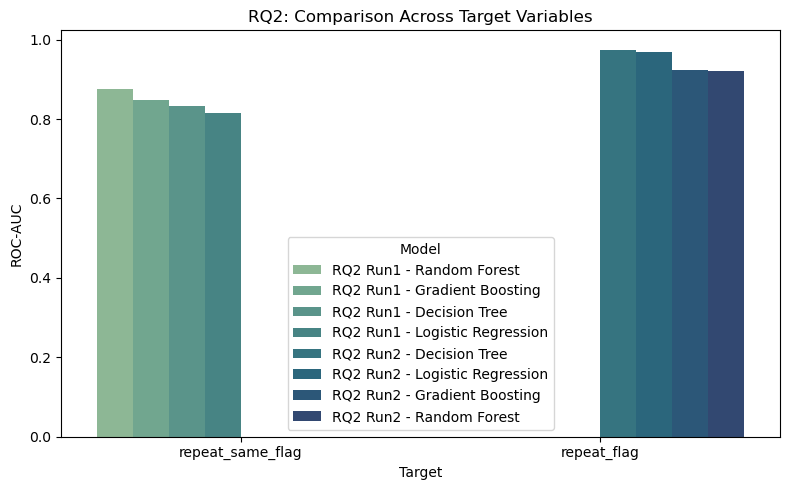


Combined RQ2 Results:
                            Model  Accuracy  Precision  Recall  F1-Score  \
0        RQ2 Run1 - Random Forest     0.814      0.957   0.824     0.885   
1    RQ2 Run1 - Gradient Boosting     0.887      0.903   0.976     0.938   
2        RQ2 Run1 - Decision Tree     0.726      0.960   0.715     0.820   
3  RQ2 Run1 - Logistic Regression     0.757      0.947   0.765     0.846   
4        RQ2 Run2 - Decision Tree     0.943      1.000   0.943     0.971   
5  RQ2 Run2 - Logistic Regression     0.914      1.000   0.914     0.955   
6    RQ2 Run2 - Gradient Boosting     0.996      0.998   0.999     0.998   
7        RQ2 Run2 - Random Forest     0.982      0.998   0.983     0.991   

   ROC-AUC            Target  
0    0.876  repeat_same_flag  
1    0.848  repeat_same_flag  
2    0.833  repeat_same_flag  
3    0.815  repeat_same_flag  
4    0.975       repeat_flag  
5    0.968       repeat_flag  
6    0.923       repeat_flag  
7    0.922       repeat_flag  


In [24]:
# ==========================================================
# RQ2 RUN 2: repeat_flag (Distinct Violations Repeated)
# full metrics + grouped % AUC
# ==========================================================
print("\n" + "="*65)
print("RQ2 RUN 2: Modeling 'repeat_flag' (Multiple Distinct Violations)")
print("="*65)

df_model2 = df_filtered.dropna(subset=cat_cols + num_cols + ['repeat_flag']).copy()
y = df_model2['repeat_flag'].astype(int)
X = df_model2[cat_cols + num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

results_diff, trained_diff = [], {}
for name, model in models_rq2.items():
    pipe = Pipeline([('pre', pre_rq2), ('model', model)])
    pipe.fit(X_train, y_train)
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    else:
        y_score = pipe.decision_function(X_test)
    y_pred = pipe.predict(X_test)
    metrics = print_classification_metrics(y_test, y_pred, y_score, label=f"RQ2 Run2 - {name}")
    results_diff.append(metrics)
    trained_diff[name] = pipe

rq2_diff_df = pd.DataFrame(results_diff).round(3).sort_values("ROC-AUC", ascending=False)
print("\nRQ2 Run 2 Model Comparison (repeat_flag):")
print(rq2_diff_df)

best_rq2_run2_name = rq2_diff_df.iloc[0]['Model'].replace("RQ2 Run2 - ", "")
best_pipe_run2 = trained_diff[best_rq2_run2_name]

gi_rq2_run2_df, auc_baseline_r2 = grouped_permutation_importance(
    best_rq2_run2, X_test, y_test,
    cat_cols=cat_cols, num_cols=num_cols,
    scoring="roc_auc", n_repeats=10, random_state=42
) if (best_rq2_run2 := best_pipe_run2) else (None, None)

print("\nRQ2 Run 2: Grouped Permutation Importance (ΔAUC and % of total ΔAUC):")
print(gi_rq2_run2_df.round(3))
print(f"\nRQ2 Run 2 Baseline ROC-AUC (best model): {auc_baseline_r2:.3f}")

# Combined overview figure (kept)
summary_rq2 = pd.concat([
    rq2_same_df.assign(Target="repeat_same_flag"),
    rq2_diff_df.assign(Target="repeat_flag")
]).reset_index(drop=True)

plt.figure(figsize=(8,5))
sns.barplot(data=summary_rq2, x="Target", y="ROC-AUC", hue="Model", palette="crest")
plt.title("RQ2: Comparison Across Target Variables")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

print("\nCombined RQ2 Results:")
print(summary_rq2)


RQ3: Are certain cuisines more associated with severe violations?

--- RQ3 - Random Forest ---
Accuracy:  0.876
Precision: 0.991
Recall:    0.883
F1-Score:  0.934
ROC-AUC:   0.649
Confusion Matrix [tn, fp; fn, tp]:
[[  286   466]
 [ 6546 49254]]

Classification Report:
               precision    recall  f1-score   support

           0      0.042     0.380     0.075       752
           1      0.991     0.883     0.934     55800

    accuracy                          0.876     56552
   macro avg      0.516     0.632     0.504     56552
weighted avg      0.978     0.876     0.922     56552


--- RQ3 - Gradient Boosting ---
Accuracy:  0.669
Precision: 0.990
Recall:    0.672
F1-Score:  0.800
ROC-AUC:   0.607
Confusion Matrix [tn, fp; fn, tp]:
[[  361   391]
 [18305 37495]]

Classification Report:
               precision    recall  f1-score   support

           0      0.019     0.480     0.037       752
           1      0.990     0.672     0.800     55800

    accuracy                

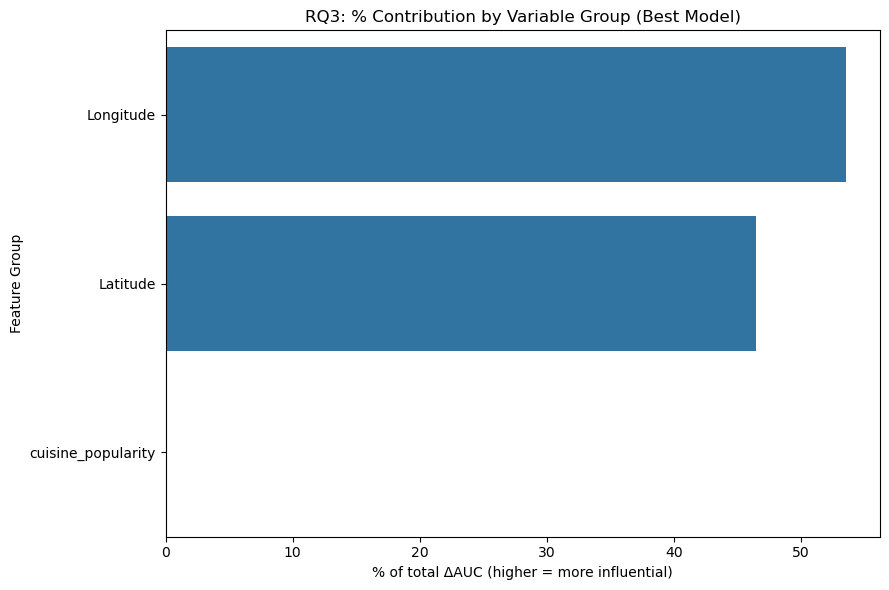

In [25]:
# ==========================================================
# RQ3: Cuisine × Geography → severe_violation (AUC + % contribution)
# Converted to Pipeline so we can compute grouped importance by original vars
# ==========================================================
print("\n" + "="*65)
print("RQ3: Are certain cuisines more associated with severe violations?")
print("="*65)

df = df_raw.copy()
dupe_keys = [k for k in ["CAMIS","INSPECTION DATE","VIOLATION CODE"] if k in df.columns]
if dupe_keys: 
    df = df.drop_duplicates(subset=dupe_keys)

df = df.dropna(subset=['BORO','CUISINE DESCRIPTION','Latitude','Longitude','CRITICAL FLAG'])
df = df[(df['Latitude']>40)&(df['Latitude']<41)&(df['Longitude']>-75)&(df['Longitude']<-73)]
df['severe_violation'] = np.where(df['CRITICAL FLAG'].str.contains('Critical', case=False, na=False), 1, 0)

# Cuisine cleaning & features
c_counts = df['CUISINE DESCRIPTION'].value_counts()
rare = c_counts[c_counts<100].index
df['cuisine_clean'] = df['CUISINE DESCRIPTION'].replace(rare,'Other')
df['cuisine_popularity'] = df['cuisine_clean'].map(df['cuisine_clean'].value_counts(normalize=True))

# Geography features (no lat/lon bins)
df['geo_cluster'] = KMeans(n_clusters=20, n_init=10, random_state=42).fit_predict(df[['Latitude','Longitude']])
nta_counts = df['NTA'].value_counts()
nta_rare = nta_counts[nta_counts<200].index
df['NTA_clean'] = df['NTA'].replace(nta_rare,'NTA_Other')

cat_cols_rq3 = ['cuisine_clean','BORO','NTA_clean','geo_cluster']
num_cols_rq3 = ['Latitude','Longitude','cuisine_popularity']
target = 'severe_violation'

df_model = df.dropna(subset=cat_cols_rq3 + num_cols_rq3 + [target]).copy()
X = df_model[cat_cols_rq3 + num_cols_rq3]
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Balance
train_df = X_train.copy(); train_df['target'] = y_train
maj = train_df[train_df['target']==1]; minr = train_df[train_df['target']==0]
minr_up = resample(minr, replace=True, n_samples=len(maj), random_state=42)
train_bal = pd.concat([maj, minr_up])
X_train_bal, y_train_bal = train_bal.drop(columns=['target']), train_bal['target']

# Preprocess
pre_rq3 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_rq3),
    ('num', StandardScaler(), num_cols_rq3)
])

models_rq3 = {
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=12, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=400, class_weight='balanced')
}

rq3_rows = []
rq3_pipes = {}
for name, clf in models_rq3.items():
    pipe = Pipeline([('pre', pre_rq3), ('model', clf)])
    pipe.fit(X_train_bal, y_train_bal)
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    else:
        y_score = pipe.decision_function(X_test)
    y_pred = pipe.predict(X_test)
    metrics = print_classification_metrics(y_test, y_pred, y_score, label=f"RQ3 - {name}")
    rq3_rows.append(metrics)
    rq3_pipes[name] = pipe

rq3_results = pd.DataFrame(rq3_rows).round(3).sort_values("ROC-AUC", ascending=False)
print("\nRQ3 Model Comparison:")
print(rq3_results)

best_rq3_name = rq3_results.iloc[0]['Model'].replace("RQ3 - ", "")
best_rq3_pipe = rq3_pipes[best_rq3_name]

gi_rq3_df, auc_baseline_rq3 = grouped_permutation_importance(
    best_rq3_pipe, X_test, y_test,
    cat_cols=cat_cols_rq3, num_cols=num_cols_rq3,
    scoring="roc_auc", n_repeats=10, random_state=42
)
print("\nRQ3: Grouped Permutation Importance (ΔAUC and % of total ΔAUC):")
print(gi_rq3_df.round(3))
print(f"\nRQ3 Baseline ROC-AUC (best model): {auc_baseline_rq3:.3f}")

# Optional: visualize top groups
plt.figure(figsize=(9,6))
top_g = gi_rq3_df.head(12)
sns.barplot(y="feature_group", x="percent_contribution", data=top_g)
plt.title("RQ3: % Contribution by Variable Group (Best Model)")
plt.xlabel("% of total ΔAUC (higher = more influential)")
plt.ylabel("Feature Group")
plt.tight_layout()
plt.show()


/var/folders/yc/dvwbsbn92dxgf68pvf773wvc0000gn/T/ipykernel_7556/3903918040.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors='coerce')
/var/folders/yc/dvwbsbn92dxgf68pvf773wvc0000gn/T/ipykernel_7556/3903918040.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors='coerce')


Dataset shape: (289847, 27)
CAMIS        int64
DBA         object
BORO        object
BUILDING    object
STREET      object
dtype: object

Missing Values:
Location Point1          289847
GRADE DATE               157043
GRADE                    148891
SCORE                     15826
VIOLATION CODE             5700
VIOLATION DESCRIPTION      5700
BIN                        5020
Community Board            3618
NTA                        3618
Council District           3617
Census Tract               3617
CUISINE DESCRIPTION        3577
ACTION                     3577
INSPECTION TYPE            3577
ZIPCODE                    2806
dtype: int64

Basic Descriptive Stats for Numeric Columns:
                          count unique  \
CAMIS                  289847.0    NaN   
DBA                      289841  24290   
BORO                     289847      6   
BUILDING                 289332   7646   
STREET                   289846   2458   
ZIPCODE                287041.0    NaN   
PHONE        

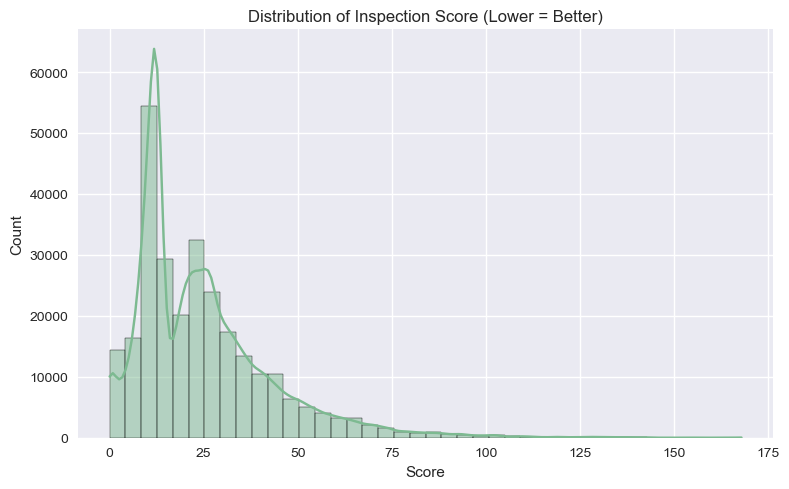

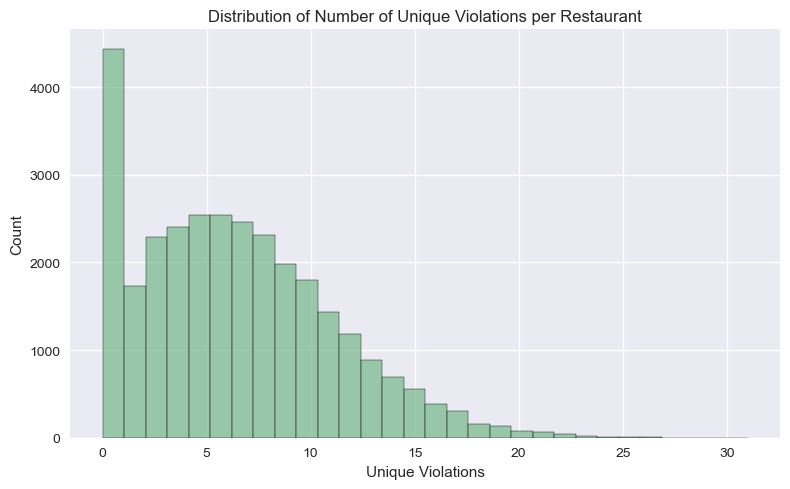

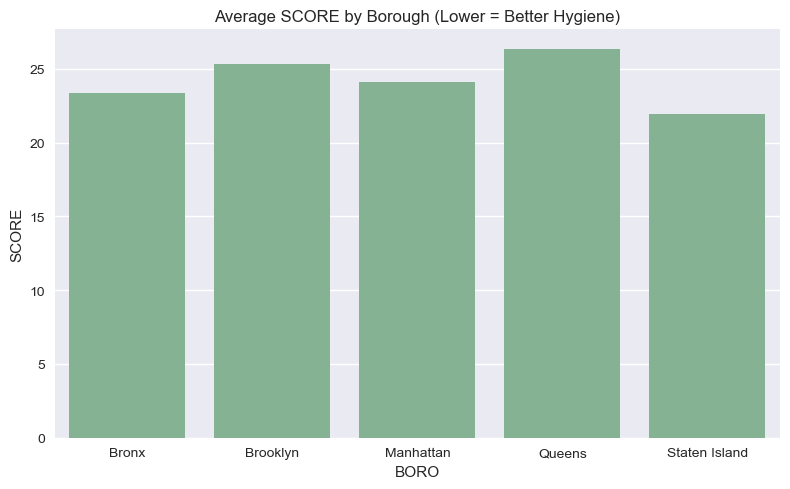

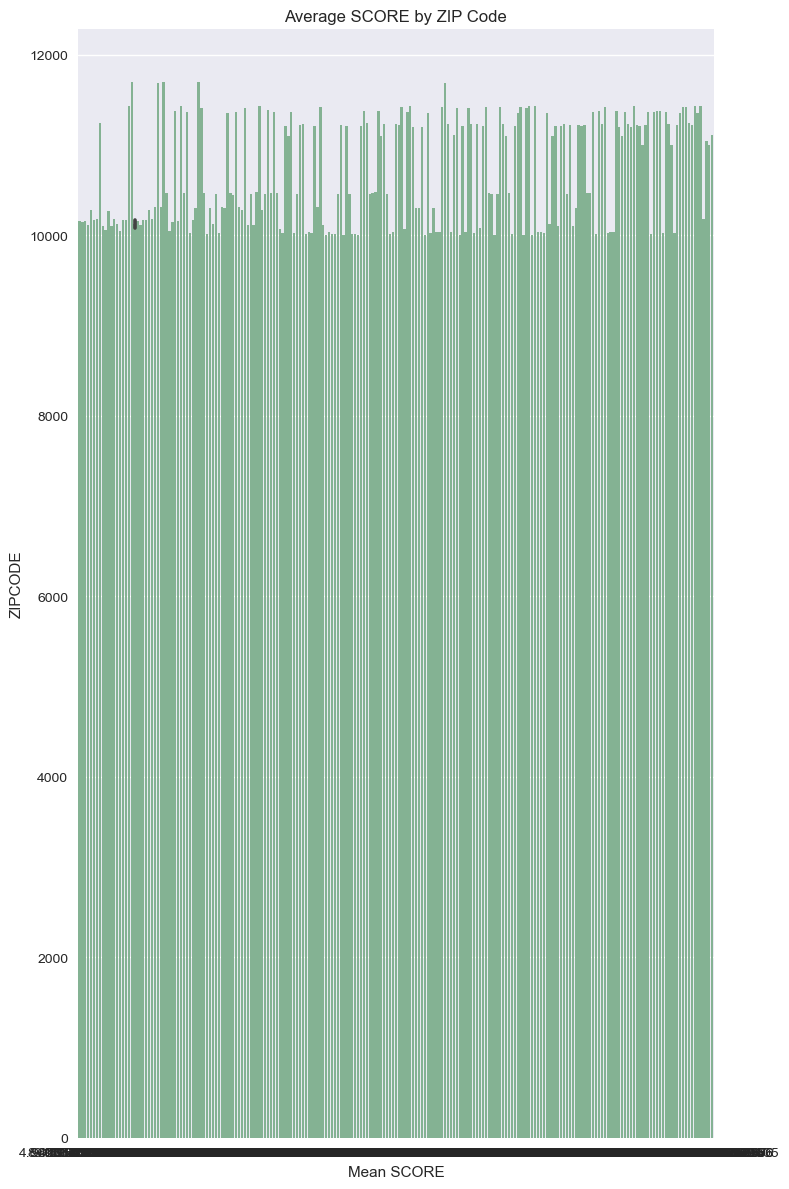

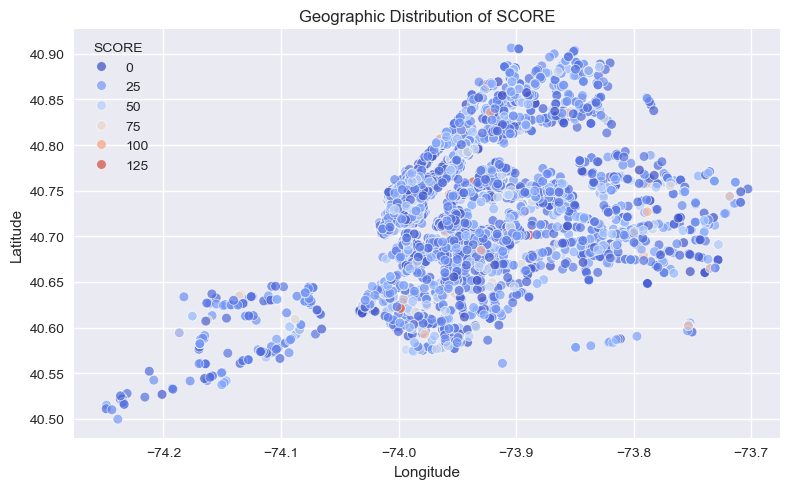

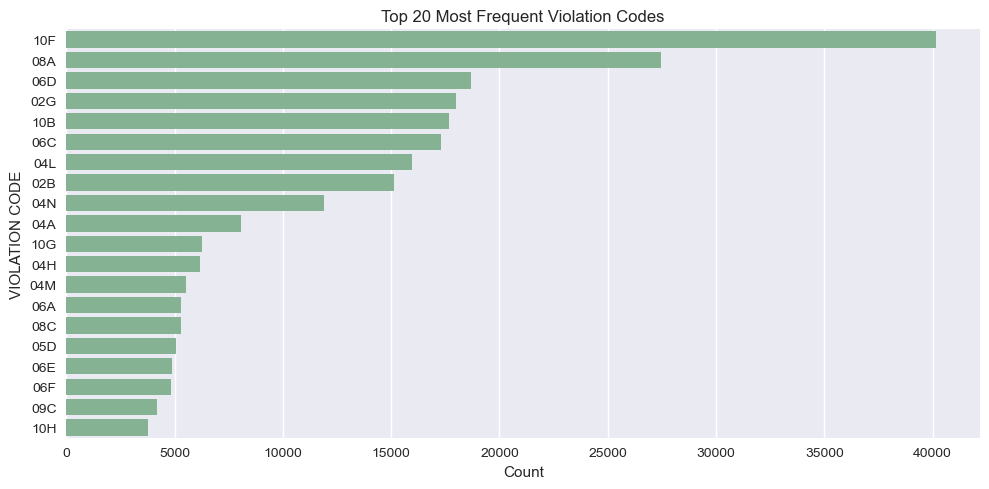

Text(0.5, 0, '# Violations')

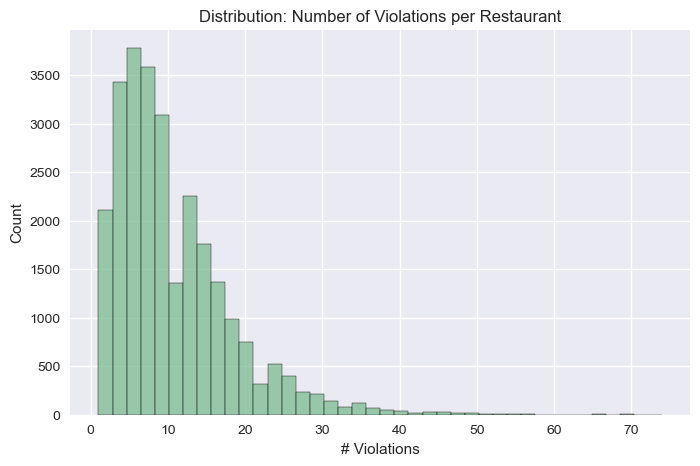

In [6]:
# ============================================================
# NYC Restaurant Inspections – EDA Aligned with RQ1, RQ2, RQ3
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("crest")

# -----------------------------
# Load Data
# -----------------------------
FILE = "DOHMH_New_York_City_Restaurant_Inspection_Results.csv"
df = pd.read_csv(FILE, low_memory=False)

# Standardize dates
for c in ['INSPECTION DATE', 'GRADE DATE', 'RECORD DATE']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

print("Dataset shape:", df.shape)
print(df.dtypes.head())

# ============================================================
# ✅ GENERAL EDA FOR FULL DATASET
# ============================================================

print("\nMissing Values:")
print(df.isna().sum().sort_values(ascending=False).head(15))

print("\nBasic Descriptive Stats for Numeric Columns:")
print(df.describe(include='all').transpose().head(20))


# -----------------------------
# Overall SCORE Distribution
# -----------------------------
if 'SCORE' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['SCORE'], bins=40, kde=True)
    plt.title("Distribution of Inspection Score (Lower = Better)")
    plt.xlabel("Score")
    plt.tight_layout()
    plt.show()

# -----------------------------
# Violations per Restaurant
# -----------------------------
plt.figure(figsize=(8,5))
viol_counts = df.groupby("CAMIS")["VIOLATION CODE"].nunique()
sns.histplot(viol_counts, bins=30)
plt.title("Distribution of Number of Unique Violations per Restaurant")
plt.xlabel("Unique Violations")
plt.tight_layout()
plt.show()

# ============================================================
# ✅ EDA FOR RQ1: Geography → Inspection Scores
# “How much variation in scores is explained by geography?”
# ============================================================

rq1 = df.copy()

# Keep relevant columns + clean
rq1 = rq1[['CAMIS','BORO','ZIPCODE','Community Board','Council District',
           'NTA','Latitude','Longitude','SCORE']].dropna()

rq1 = rq1[(rq1['Latitude']>40)&(rq1['Latitude']<41)&
          (rq1['Longitude']<-73)&(rq1['Longitude']>-75)]

# Mean score per borough
boro_mean = rq1.groupby("BORO")["SCORE"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=boro_mean, x='BORO', y='SCORE')
plt.title("Average SCORE by Borough (Lower = Better Hygiene)")
plt.tight_layout()
plt.show()

# Score heatmap by ZIP
zip_mean = rq1.groupby("ZIPCODE")["SCORE"].mean().sort_values()

plt.figure(figsize=(8,12))
sns.barplot(x=zip_mean.values, y=zip_mean.index)
plt.title("Average SCORE by ZIP Code")
plt.xlabel("Mean SCORE")
plt.tight_layout()
plt.show()

# Latitude vs SCORE
plt.figure(figsize=(8,5))
sns.scatterplot(data=rq1.sample(5000), x='Longitude', y='Latitude',
                hue='SCORE', palette='coolwarm', alpha=0.7)
plt.title("Geographic Distribution of SCORE")
plt.tight_layout()
plt.show()

# ============================================================
# ✅ EDA FOR RQ2: Repeat Violations
# “Do restaurants repeatedly commit the same types of violations?”
# ============================================================

rq2 = df.copy()
rq2 = rq2.dropna(subset=['CAMIS','VIOLATION CODE'])

# Frequency of each violation code
plt.figure(figsize=(10,5))
top_viol = rq2['VIOLATION CODE'].value_counts().head(20)
sns.barplot(x=top_viol.values, y=top_viol.index)
plt.title("Top 20 Most Frequent Violation Codes")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# Count violations per restaurant
viol_per_rest = rq2.groupby("CAMIS")["VIOLATION CODE"].count()

plt.figure(figsize=(8,5))
sns.histplot(viol_per_rest, bins=40)
plt.title("Distribution: Number of Violations per Restaurant")
plt.xlabel("# Violations")


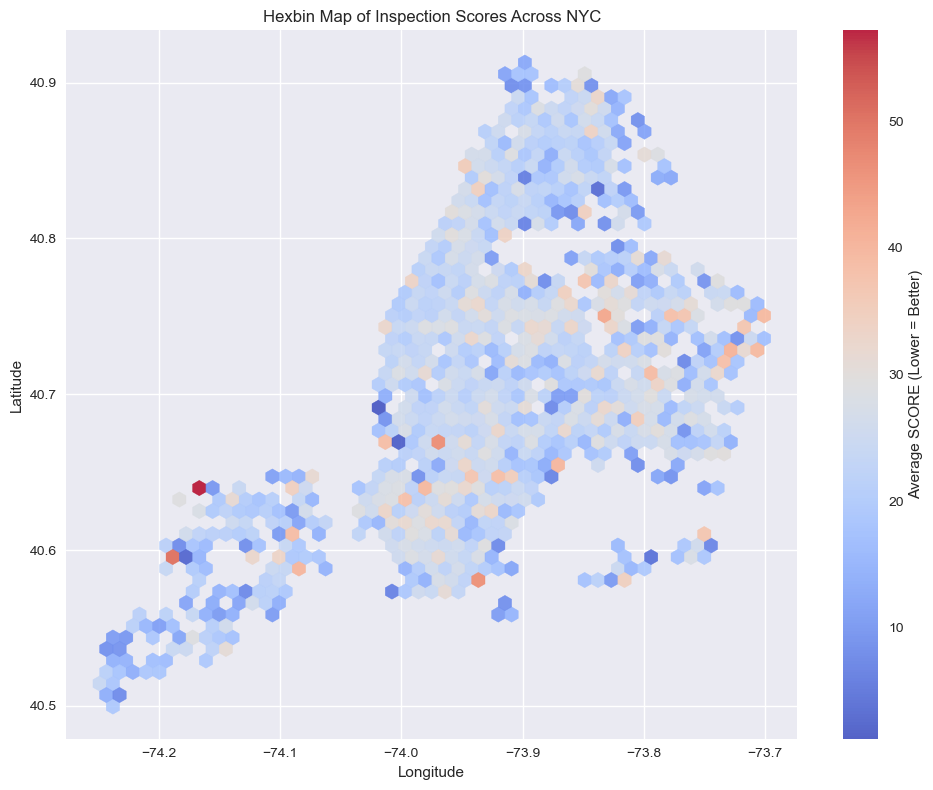

In [7]:
# ============================================================
# Geographic Hexbin Visualization (Recommended)
# ============================================================

plt.figure(figsize=(10, 8))

hb = plt.hexbin(
    rq1["Longitude"],
    rq1["Latitude"],
    C=rq1["SCORE"],
    gridsize=50,
    cmap="coolwarm",
    reduce_C_function=np.mean,
    mincnt=1,
    alpha=0.85
)

plt.colorbar(hb, label="Average SCORE (Lower = Better)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Hexbin Map of Inspection Scores Across NYC")
plt.tight_layout()
plt.show()

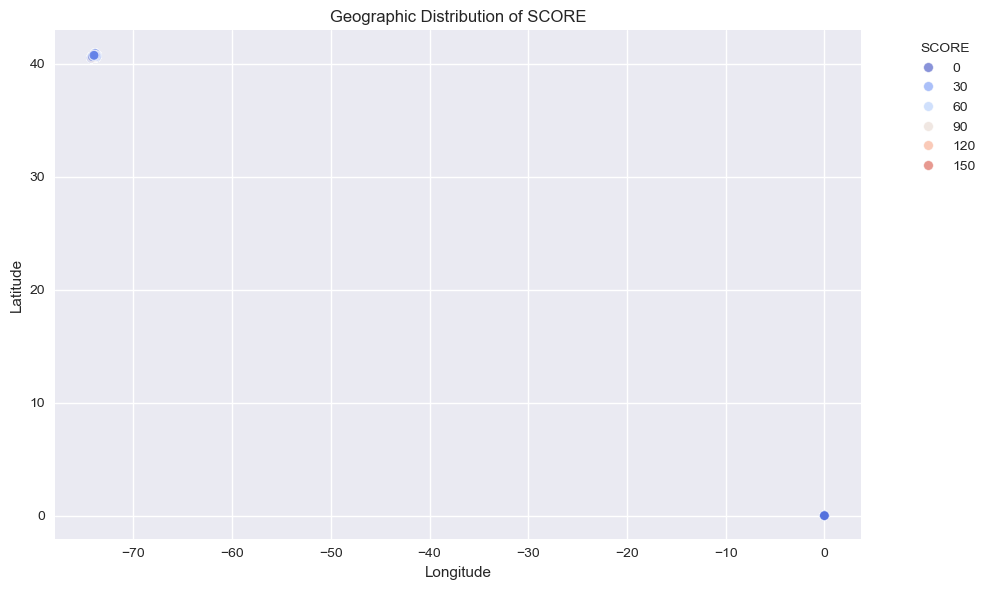

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_raw,
    x='Longitude',
    y='Latitude',
    hue='SCORE',
    palette='coolwarm',
    alpha=0.6
)

plt.title("Geographic Distribution of SCORE")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="SCORE", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(20, 12))
sns.heatmap(
    df_raw.isnull(),
    cmap="rocket_r",
    cbar=False,
    yticklabels=False
)

plt.xticks(rotation=90)
plt.title("Missing Values Heatmap for NYC DOHMH Inspection Dataset", fontsize=16)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Inspection Records", fontsize=12)
plt.tight_layout()
plt.show()